# 01 Prediction analysis of in-game spending for SLG multiplayer online mobile game

This case is about in-game spending prediction based on user behavior data of SLG mobile game "Brutal Age". The data of this case comes from the second Smart China Cup (ICC) of DC competition**. "Brutal Age" is a SLG-type mobile game that is popular all over the world. According to App Annie statistics, "Brutal Age" ranked first in the game best-selling list in 12 countries, and ranked in the top 10 in the game best-selling list in 82 countries. Accurately understanding the value of each player is of great significance to the game's advertising strategy and efficient operational activities (such as accurate promotions and gift pack recommendations), and helps bring a more personalized experience to players. Therefore, we hope to accurately estimate the value of players in the early stages of entering the game. In this competition, **we will use players’ behavior data in the first 7 days in the game to predict the total payment amount of each of them within 45 days**. 

- Data source: Chengdu Nibiru Technology Co., Ltd. (English logo: tap4fun) provided to DC officials for data competition
- Data level: millions
- Prediction type: regression class
- Algorithms involved: linear regression, logistic regression, random forest, GBDT

## Case Directory

**1. Game industry - the rapidly developing new entertainment industry and new scenarios for the implementation of data technology**<br><br>
**2. Game data analysis/game algorithm position overview**<br><br>
**3. From traffic to monetization: a detailed explanation of the operating model of mobile games**<br><br>
**4. Sweet Trap: How do you move towards earning money step by step? **<br><br>
**5. Games and data: 6 typical scenarios where data technology assists game operations**<br><br>
**6. Data Exploration: In-depth exploration of game user behavior data**<br>
- 1. Import data and understand the basic information of the data<br>
    1.1 Understand the characteristics of SLG game data<br>
    1.2 Missing/duplicate values<br>
- 2. Exploration of tags: important indicators and operating status of game management<br>
- 3. Exploration of features<br>
    3.1 Online duration: Are users losing at an abnormal rate? <br>
    3.2 Distribution and Skewness: Is the game newbie-friendly? Is the game difficulty setting reasonable? <br>
    3.3 Game balance: The impact of in-game spending on the combat system<br>
    3.4 Left bias brings long tail: Who is the abnormal player? <br>

**7. Model Construction: Predicting user spending behavior from 0**<br>
- 1. Guide database and integrated data<br>
- 2. Data preprocessing: correlation between registration time and in-game spending status<br>
- 3. Model selection and establishment of model benchmark<br>
- 4. Feature Engineering (1): Add new features according to business model<br>
    4.1 New business indicators and new features<br>
    4.2 Add new features based on business conclusions<br>
- 5. Feature Engineering (2): Achieving the statistical assumptions required for modeling<br>
    5.1 Relevance analysis: filtering features/feature importance<br>
    5.2 Tuning of training/test set split<br>
    5.3 Exception value processing<br>
    5.4 Normalization processing<br>
    5.5 Normalization processing<br>
- 6. Model fusion: dealing with problems caused by extreme skewness, anomalies and data volume<br>
- 7. Model Tuning<br> 

————————

## Game industry - the rapidly developing new entertainment industry, new scenarios for the implementation of data technology

- In the past 10 years, games have become one of the most important forms of entertainment
> - The total global gaming output value was approximately US$11 billion in 2010 and is now US$170 billion<br>**Exceeding the combined output value of the global television and film industries**<br><br>
> - In 2009, the three domestic game giants (Tencent, Shanda, and NetEase) had a total annual revenue of 13.56 billion yuan. In 2020, Tencent alone's game revenue reached 156.1 billion yuan, and NetEase's revenue was 54.61 billion yuan<br> (This actually happened on the basis that a large number of games can be played for free)<br><br>
> - Games have become the center of cultural life, players focus on in-depth systems/narratives/interactions, and have the ability to appreciate and identify games<br>**The main force of players has shifted from children to adults**<br><br>
> - The status of game players/developers has increased significantly, e-sports has become an Olympic sport, anchors and game directors have become superstars, politicians have joked about "PokemonGo" during the presidential election, and "Fortnite" dances have appeared at the World Cup...

- The rapid expansion of the industry scale has benefited from **bold exploration**, also benefited from **historical process**, and is also related to the lack of supervision<br><br>
- The rise of mobile Internet has fundamentally changed the face of the game industry
> - Mobile games have become the most profitable gaming format in the world<br>2000 - Mainly FC consoles, arcades, handheld PSPs and PCs<br>2010 - With the development of the Internet, the scale of global client games and online games has expanded dramatically<br>2021 - Mobile games accounted for 76.37% of sales revenue in the Chinese market, client games accounted for 19.6%, and online games accounted for 1.99%<br><br>
> - The development of the Internet/digital shopping mall/hardware technology has led to the rapid expansion of gaming platforms/devices<br>The **access threshold for games has been significantly lowered**, and we do not need to go into Internet cafes/game arcades/sit in front of home computers to play games<br>This has greatly expanded the **potential game population base**, making it possible for new profit strategies and the establishment of game culture<br>The development threshold for games has also been significantly lowered, independent games are frequent, and large game companies also need to compete with small teams for creativity.
<br><br>
> - The profit strategy has undergone drastic changes, and the conversion link relying on the Internet has become relatively mature<br>2000 - Offline sales of game copyrights (CDs/FC cards) require equipment/game software<br>2005 - Sales of game time (point cards)/participation rights (QQ Game Hall), games require payment Only fees can participate<br>2010 - The model of free games and paid value-added services has taken shape, and a large number of games survive at the cost of destroying balance<br>2020 - The free games and value-added payment models are basically mature, and efficient and easy-to-accept payment models are blooming everywhere<br><br>
> - Game culture is gradually established, and the "game stigma" phenomenon has improved<br>Game practitioners have gained more respect

- Current situation: sustained development, fierce competition, policy whips and sugar coexist, and the industry is gradually becoming formalized<br>
> - In the first half of 2021, domestic game sales revenue was 150.493 billion yuan, a year-on-year increase of 7.89%, with a stable growth rate<br><br>
> - Version number restrictions are strict, and policies force companies to turn to the route of high-quality games (the road of skin reskin + purchase volume is no longer feasible)<br><br>
> - In September 2021, relevant persons in charge of the Central Propaganda Department and the State Press and Publication Administration, Tencent, NetEase and other game companies, controlled disorderly competition in capital<br><br>
> - Affected by the national regulations on the restriction of games for minors and the Economic Information Daily’s article “Honor of Kings is the spiritual opium”, the growth of domestic user base has slowed down<br><br>
> - Competition in the domestic market is fierce, with giants and dark horses constantly competing, and the Red Sea situation continuing<br>**Holding the position/refined operations/localized operations have become more important**<br><br>
> - Domestic games are "going out", and the country is pushing game exports to encourage the construction of a global development pattern<br>In the distribution of self-developed export game types -<br> - **Simulation management/strategy games (SLG, such as Awakening of Nations, Jiangnan White Scenery) accounted for 41.47%**<br> - First-person shooter games (FPS, such as PlayerUnknown's Battlegrounds) accounted for 13.58%<br> - Role-playing/turn-based RPGs (MMORPGs, such as Genshin Impact, Onmyoji) account for 12.25%<br><br>
> - Domestic original IP research and development capabilities have been improved, and independent original game product innovation capabilities have generally been enhanced<br><br>

————————

## Game data analysis/game algorithm position overview

- **Large companies and giants give priority to the recruitment trend, and the job salaries are considerable**<br>

![](https://skojiangdoc.oss-cn-beijing.aliyuncs.com/micro_class/sklearncase/腾讯.png?versionId=CAEQHxiBgIDgvYir4RciIGY1MTc2NmEyYjViOTRhNjBiNjQyYmExODkxNjljMjBj)

![](https://skojiangdoc.oss-cn-beijing.aliyuncs.com/micro_class/sklearncase/腾讯2.png?versionId=CAEQHxiBgICkgpOr4RciIDQ1MmYwMTc5ZDY5ZjRkOTg5YWIzN2E1ZmMzN2YyYTg5)

![](https://skojiangdoc.oss-cn-beijing.aliyuncs.com/micro_class/sklearncase/腾讯3.png?versionId=CAEQHxiBgIDthJOr4RciIDgxMmJiZTNkODgxYzRkYTRhNzM0ZTI1YmI5NzQ2ZjYy)

![](https://skojiangdoc.oss-cn-beijing.aliyuncs.com/micro_class/sklearncase/网易.png?versionId=CAEQHxiBgMDHz4ir4RciIDFmZmQ2ODc0ZjUwZTRkNGFhMTdiMzI5YWYxNTNmZDhh)

![](https://skojiangdoc.oss-cn-beijing.aliyuncs.com/micro_class/sklearncase/字节.png?versionId=CAEQHxiBgIDk1Yir4RciIDIwYTY3ODkwYzRiNzQ4MTU5YWJlM2YzODI2MTFjNTQ1)

- **There are many positions in large and medium-sized game companies/Internet companies**<br>
Search "game analysis" on the recruitment website to get a large amount of job information instantly...<br>

- **Recruitment throughout the year, many campus recruitment positions**<br>

![](https://skojiangdoc.oss-cn-beijing.aliyuncs.com/micro_class/sklearncase/捕获.PNG?versionId=CAEQHxiBgMC594er4RciIDZlYmFmYmRiNWE2YzRhODFiZTZiYjdlZWM5MmQ0YmRh)

![](https://skojiangdoc.oss-cn-beijing.aliyuncs.com/micro_class/sklearncase/岗位2.PNG?versionId=CAEQHxiBgIDChpOr4RciIDU0ODAzMjM1ZTE4ZTRkYzdiNjRlOWVkMjRhNDRlZjM4)

![](https://skojiangdoc.oss-cn-beijing.aliyuncs.com/micro_class/sklearncase/岗位3.png?versionId=CAEQHxiBgICBh5Or4RciIGEwZTJlYWM3ODE1ZDRlOGZhNTlmZTU0ZjQ3MWQ0ZTY0)

- **Under the existing policies and market conditions, try not to go to a small company for your first game analysis job**

————————

## From traffic to monetization: a detailed explanation of the operating model of mobile games

In the past ten years, mobile games have proven their ability to attract money. Behind this ability is the carefully designed and tempered operational link of game developers. Products/services exert value around this link, forming the value creation chain of the mobile game industry. Every industry and every enterprise has a unique value creation chain. **Data technology workers act at key nodes of these value chains and influence the entire value creation process** by influencing key decisions. Therefore, to understand the value of data workers’ work, we must understand the value chain behind the industry.

One of the core manifestations of value is income, so the first step in dismantling an industry is often to figure out the question "where does the income come from?" This involves three major aspects: the way the industry charges, the products/services the industry provides, and the channels the industry relies on. Understanding the ways in which different companies in different industries obtain revenue allows us to understand the product/service matrix provided by the company/industry. One of the key responsibilities of data technology workers is to optimize these products/services themselves, or to optimize the combination of products/services. In the Internet age, the fragrance of wine is also afraid of the deep alley. Good products/services need to be seen by the public and need to be displayed on their own platform to achieve traffic acquisition or transaction. Therefore, **optimization of operating channels/sales methods** is also one of the responsibilities of data technology workers.

Fortunately, the revenue sources and services provided by the gaming industry are very obvious to users (unlike some other popular areas of the Internet, it is difficult to judge where a company's revenue comes from without in-depth thinking, such as WeChat and Douyin). <br><br>

The income sources of various games can basically be divided into the following points:

- **Users pay within the game to purchase services/products in the game** (also known as in-game spending)<br><br>
- **Download and Installation** (Pay to download the APP or pay through STEAM and other platforms)<br><br>
- **Merchant sponsorship or naming** (the sports car that appears in the game is the logo of a certain famous car, and certain logos are printed on the buildings in the game)<br><br>
- **Embedded Ads** (need to watch ads to unlock levels, shorten time, etc.)<br><br>
- **Game Competition** (You need to pay to participate, the event has titles and bonuses, etc.)<br><br>

The products and services provided by game developers are the game experience itself, or peripherals related to the game IP.

Among all the above incomes, the main source of income for mobile games is user in-game payments, which is also called "in-game spending." Even if you have never been exposed to the gaming industry, you should have heard about the power of "in-game spending" (you may have heard news about people spending huge sums of money for rare items in their game accounts). in-game spending is indeed the core source of revenue in the game industry, so what is the link from traffic to users to in-game spending? Let's take a look -

The operating model/operational link of mobile games is actually a relatively common model in the Internet traffic war. It can be macro-divided into four steps: user acquisition (seizing traffic), user retention, user activation, and operational transformation. Although the types of mobile games are ever-changing, their value chain has always been built around these four processes. The main objects of game monetization and transformation are users (that is, players) themselves, and whether users grow, retain, and are active will be highly dependent on the game experience and the smoothness of the conversion link itself. Let’s take a look at the following process: 

![](https://skojiangdoc.oss-cn-beijing.aliyuncs.com/micro_class/sklearncase/游戏链路.PNG?versionId=CAEQHxiBgIDcv86s4RciIDI2M2EwYTNkYWI3MjRiZDlhY2Y5NjBkNWQ2MWY1ZThm)

Almost all new activities, new functions, and new gameplay are designed according to the above process. The goal of these new experiences must be more users, more activity, or more effective monetization, and different goals point to different analysis methods and indicators. You can follow this idea to analyze the new features of the games you have been playing recently.

It should be noted that although many products and services in the mobile Internet field rely on the above process for transformation, due to the different nature of the goods, different objects of realization, different methods of realization, etc., the actual operation of executing this process is very different for each industry.

To give an easy-to-understand example - short video platforms such as Douyin and Kuaishou often mention key indicators such as new acquisitions, conversions, and retention during operations, but they do not rely on the users who watch the videos themselves to convert, nor can they fully control the experience brought by the APP itself to deepen user stickiness. In contrast, users of short video platforms are attracted by attention commodities (video content), and these video contents are also produced by users. Therefore, what short video platforms need is a mechanism to encourage high-quality content. The income sources of short video platforms are advertising space fees, live broadcast e-commerce service fees/handling fees, etc., so user stickiness and monetization are not directly related (that is, you may spend a lot of time watching videos, but not even glance at the advertising recommendations. In contrast, if you play a game for a long time, as long as you design the game experience a little, you may easily take the step of earning money). The mechanism of short videos will be more complex and related to more third parties.

Have you heard of a metaphor that is widely circulated in the Internet industry? The way to make money in the Internet industry is to first plant some grass, attract a group of sheep to graze, and then pen the sheep and charge a fee for the wolves who want to eat the sheep. This is an excellent description of the short video platform. In contrast, the game industry first plants grass (the grass must be delicious and addictive), lets the sheep eat the grass, and then pens the sheep, making the sheep pay for grass that grows better, eats faster, and grows fatter after eating. Sometimes, they can also incite these sheep that can afford higher-grade grass to despise ordinary sheep. Notice the difference? 

————————

## Sweet Trap: How did you move towards earning money step by step? 

<<<U16>>Now we have understood the game's operational link. In theory, we believe that this link is naturally accessible, but in fact it takes a lot of effort to move from traffic to conversion. After all, in the minds of many users, paying for games is not strictly necessary (it may even be a waste). Most people are not naturally willing to pay high fees for short-term entertainment. Therefore, game developers have been exploring the payment model for more than ten years before finally creating a set of "sweet traps" that allow some users to spend money willingly or even unknowingly spend a lot of money. 

![](https://skojiangdoc.oss-cn-beijing.aliyuncs.com/micro_class/sklearncase/revenue.PNG?versionId=CAEQHxiBgIDon6Gv4RciIDFmNGY4ZDZiODk1OTQ3ZTY4ZGViNDUwZjI3NTIwZjdm)

 Even the game with the simplest model (Xiaoxiaole) can rely on the game experience design to make a steady profit, ranking among the top ten in the global mobile game revenue list for many years. 

The main way to earn gold is to allow users to pay within the game, but specifically, it mainly uses the following three conditions to prompt users to pay:

1. Create **itch** or even **pain** in the game to incite players’ emotions 

> - **itch**<br><br>Xiaoxiaole - I want to play the subsequent levels, but I have no lives/I am only a little bit close to passing the level, but there are no steps left<br><br>Onmyoji/FGO - New characters/new skins/new avatar frames are so cool, I want them so much<br><br>Some story-based games - the options that obviously trigger heartbeat plots are paid, I really want to know what will happen.

> - **Pain**<br><br>I can never win in PVP. I finally played a game and was beaten to the point of being violent.<br><br>The resources I had saved for a long time were all used to draw cards, and not a single useful one came out<br><br>This level has been completed. I have replayed it 30 times and it still hasn’t passed, and I don’t even see any hope of passing the level<br><br>There is a serious lack of skills/resources, the production of resources takes too long, development cannot continue, and the main plot cannot be advanced<br><br>

2. Allow players to buy products and services that can gain more competitive advantages, higher levels of psychological satisfaction, and deeper experiences, so as to eliminate the itch** and gain **refreshment**

> - Competitive advantages - such as purchasing more advanced weapons and equipment, purchasing props that provide more experience, shortening waiting time, etc.<br>
> - Psychological satisfaction - such as skins, avatar frames, achievements, titles, rare decorations, etc.<br>
> - Deep experience - such as card drawing coupons, number of lives, paid unlocking of more levels, paid plot lines, paid copies, etc.<br><br>
(It is not difficult to find that most of these payment points are driven by emotion rather than reason. Therefore, compared with e-commerce, education and other industries, transactions in the game industry have a great relationship with experience, and are not so related to the objective needs of the users themselves) 

<<<U22>>Similarly, when there are some problems in the game (such as bugs and disputes) and players need to be appeased, the above three products and services can also be used to appease users. 

3. Lower the user payment threshold by **low price and multiple times**

When users pay for "itch", the cost must be low, and when users pay for "pain", the comfort must be strong, otherwise users will feel the malicious intent of the game operator. Therefore, transaction costs in games are often relatively low. Generally, the minimum single transaction value is less than 10 yuan or 15 yuan, and the maximum amount is not too high. Game users tend to start from a "small" amount of money, spend more and more, and finally have a higher accumulated value. 

<<<U25>>Now you know how you fell into the trap of game operators. 

————————

## Games and data: 6 typical scenarios where data technology assists game operations

![](https://skojiangdoc.oss-cn-beijing.aliyuncs.com/micro_class/sklearncase/游戏链路.PNG?versionId=CAEQHxiBgIDcv86s4RciIDI2M2EwYTNkYWI3MjRiZDlhY2Y5NjBkNWQ2MWY1ZThm)

Whether it is from the perspective of the key points of in-game spending experience design or the traffic monetization process, game experience has always been a very important part of game operations. Therefore, the work of game analysts/game algorithm engineers basically revolves around **evaluating/improving the effects of game experience**.

For example, game analysts often conduct analysis around the promotion and conversion effects of newly launched functions, new experiences, and new activities. Therefore, they will pay great attention to key indicators such as daily activity, retention, visits, number of sessions (for games, a session means at least performing some kind of game operation, for example, some people may log in to the game but not play, even if they visit but do not have a session), conversions, and retention after conversion. In the process of monetization and conversion, data workers may even take on the responsibility of creating user portraits and conducting hierarchical marketing for users. In a worse case scenario, the above-mentioned links may not exist, so data workers need to build links from scratch and assist in creating models. After the models and links are established, they can continuously strengthen the closed loop of income and experience to achieve scale expansion. 

In actual work, the effect feedback data of the game experience is player behavior data, which may be data on the player's various resources/levels, or data such as click paths. In this link, we can summarize 6 typical scenarios where data technology assists game operations:

- **1 [Channel] Advertising channel/content analysis**<br>Judge the most suitable channel for the current game from the traffic conversion rate, channel cost, user retention rate and other information of different channels<br>Or judge the most suitable advertising content for the current game/Judge the most suitable advertising content for the current channel<br>Based on historical data, predict the effect of old channels on new content/predict the effect of new channels<br><br>
- **2 [Retention] Player retention analysis on the next day/3rd/7th/30th day**<br>From the player behavior data, resource accumulation/level height/online duration/final retention and other information, determine the key factors that affect player retention<br>From the click path, page stop Conduct attribution analysis on retention time, interface access and other data to hide the last behavior of players before churn and determine the reasons for churn<br>Based on churn time and other information, determine player stickiness and assist in designing mechanisms and functions to increase new user stickiness/revitalize old users<br><br>
- **3 [Activity Promotion] Daily user activity monitoring**<br>Monitor daily game data and issue daily reports with indicators such as daily activity, daily sessions, daily churn, daily conversion rate, etc.<br>Timely capture/feedback of unsmooth points in the game process (such as points where the conversion rate drops sharply, or functions with low participation), and assist in optimizing the game process/process<br><br>
- **4 [New launch] Monitoring of promotion effects after launching new functions/new products/monitoring of conversion effects after launching new operating activities**<br>Complete ABtest before launching new functions, complete prediction of new functions/new product effects, and assist in new launch decisions<br>Monitor the promotion efficiency when new functions are launched, and issue new launch reports with indicators such as daily increase, session increase, lost return visits, conversion rate growth, etc.<br>Monitor the impact of new functions/new conversion activities on other game functions/game balance<br><br>
- **5 [User] Draw user portraits to complete user life cycle management**<br> Calculate user life cycles from player retention/activity data (online time, whether to churn, churn time, whether to spend money, etc.)<br> Draw user portraits for each life cycle from player registration data (such as ID number, gender, bound social accounts)<br> To assist in operational promotion material preparation/channel selection/user life cycle management<br><br>
- **6 [Conversion] Special analysis of revenue/conversion/marketing**<br>Monitor daily game revenue data and issue daily/activity revenue reports with indicators such as full-server ARPU, full-server total revenue, conversion rate, etc.<br>Analyze the game product matrix to assist in determining activity frequency, new product development direction, and more related marketing strategies Matters<br>Draw user consumption portraits based on player behavior data (first time gold spend, first time gold spend, cumulative gold spend, lack of resources, experience level, etc.)<br>According to various user portraits and analysis results, formulate precise marketing strategies to assist in increasing revenue<br><br>

<<<U29>>In addition to the content listed above, game analysts/algorithm engineers may do the following:

1. **Abnormal Monitoring** - Monitor whether there are abnormal accounts, hang-up/cheating, etc. (such as continuous online within 72 hours/or short online time, no money but abnormally rich resources)<br><br>
2. **Load Monitoring** - Whether the server is running normally, the load needs to be predicted before the event/contest starts to ensure sufficient hardware resources, etc.<br><br>
3. **Best-selling product analysis/sales forecast** - If there are a large number of products in your game mall and no one understands the overall situation of the product, then you may need this type of analysis 

As long as the corresponding data exists, any of the above scenarios can be explained as a case. In a game, if we have enough costs, we should introduce different functions and use different promotion and new methods for users with different life cycles, different consumption behaviors, and different profiles, so as to extend the user life cycle and deepen the user's entertainment depth as much as possible, so as to promote more conversions. If our costs are insufficient, we should focus on products with the highest conversion efficiency and help game planners make these products more "gentle" and still try to extend the user life cycle.

After understanding how data contributes to the value of the game business, I believe you have understood that our case "In-Game Spending Prediction Analysis of SLG Multiplayer Online Mobile Game" belongs to the analysis case of the revenue/conversion/marketing section, but by extension, it can also belong to the case of the user section. In this case, we will use the behavioral data from the 7 days before registration to predict how much they will spend in the next 45 days. This prediction points to conversion on the one hand and **comprehensive user value** on the other. Users who pay more within 45 days are higher-value users. If the user value can be predicted in the early stage of operation, the game operator can more accurately target high-value users for marketing (which is similar to big data for users, but for game operators For the game operator, it is an effective way to increase revenue. "Shi Lin Guang Ji" says that kindness does not control the army, and justice does not obey the government. As analysts/algorithm engineers who provide decision-making information to the game operator, we can only analyze it from the perspective of the operator).

————————

## Data exploration: in-depth exploration of game user behavior data

<<<U32>>### 1. Import data and understand the basic information of the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['font.sans-serif']=['Simhei'] # Let the Chinese characters on the pictures in jupyter be displayed
plt.rcParams['axes.unicode_minus']=False

In [2]:
data = pd.read_csv(r"数据\tap4fun竞赛数据\tap_fun_train.csv")

In [3]:
data.head() #View the general content of the data

,user_id,register_time,wood_add_value,wood_reduce_value,stone_add_value,stone_reduce_value,ivory_add_value,ivory_reduce_value,meat_add_value,meat_reduce_value,...,pvp_battle_count,pvp_lanch_count,pvp_win_count,pve_battle_count,pve_lanch_count,pve_win_count,avg_online_minutes,pay_price,pay_count,prediction_pay_price
0,1,2018-02-02 19:47:15,20125.0,3700.0,0.0,0.0,0.0,0.0,16375.0,2000.0,...,0,0,0,0,0,0,0.333333,0.0,0,0.0
1,1593,2018-01-26 00:01:05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0.333333,0.0,0,0.0
2,1594,2018-01-26 00:01:58,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,1.166667,0.0,0,0.0
3,1595,2018-01-26 00:02:13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,3.166667,0.0,0,0.0
4,1596,2018-01-26 00:02:46,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,2.333333,0.0,0,0.0


<<<U35>>#### Check the number of samples/number of features

In [4]:
data.shape # Among the 109 features, the first column is the player ID, and the last column is the tag's 45-day payment amount, so the actual number of features is 107 features

(2288007, 109)

In [5]:
#At the same time, when this amount of data is run on a personal computer, we will tend to use simpler and faster models instead of complex models

<<<U38>>#### Change the column name to Chinese

In [6]:
column_name = pd.read_excel(r"数据\tap4fun竞赛数据\tap4fun 数据字段解释.xlsx")

In [7]:
column_name.head()

,字段名,字段解释,数据时间,变量性质,字段类型,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,user_id,玩家唯一ID,永久,ID,ID,目标：使用玩家在前7日的行为数据，预测玩家前45日付费金额。,NaN,NaN
1,register_time,玩家注册时间,永久,自变量,注册时间,NaN,NaN,NaN
2,wood_add_value,木头获取数量,前七日,自变量,物资,NaN,NaN,NaN
3,wood_reduce_value,木头消耗数量,前七日,自变量,物资,NaN,NaN,NaN
4,stone_add_value,石头获取数量,前七日,自变量,物资,NaN,NaN,NaN


In [8]:
data.columns

Index(['user_id', 'register_time', 'wood_add_value', 'wood_reduce_value',
       'stone_add_value', 'stone_reduce_value', 'ivory_add_value',
       'ivory_reduce_value', 'meat_add_value', 'meat_reduce_value',
       ...
       'pvp_battle_count', 'pvp_lanch_count', 'pvp_win_count',
       'pve_battle_count', 'pve_lanch_count', 'pve_win_count',
       'avg_online_minutes', 'pay_price', 'pay_count', 'prediction_pay_price'],
      dtype='object', length=109)

In [9]:
data.columns = column_name["字段解释"]

In [10]:
data.head()

字段解释,玩家唯一ID,玩家注册时间,木头获取数量,木头消耗数量,石头获取数量,石头消耗数量,象牙获取数量,象牙消耗数量,肉获取数量,肉消耗数量,...,PVP次数,主动发起PVP次数,PVP胜利次数,PVE次数,主动发起PVE次数,PVE胜利次数,在线时长,付费金额,付费次数,45日付费金额
0,1,2018-02-02 19:47:15,20125.0,3700.0,0.0,0.0,0.0,0.0,16375.0,2000.0,...,0,0,0,0,0,0,0.333333,0.0,0,0.0
1,1593,2018-01-26 00:01:05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0.333333,0.0,0,0.0
2,1594,2018-01-26 00:01:58,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,1.166667,0.0,0,0.0
3,1595,2018-01-26 00:02:13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,3.166667,0.0,0,0.0
4,1596,2018-01-26 00:02:46,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,2.333333,0.0,0,0.0


#### Understanding features: Basic overview of SLG games

In order to understand the characteristics of game data and successfully analyze the characteristics, we must understand the basic overview of the game. Although the basic conversion link of games is universal, it is different from e-commerce, short videos and other fields where universal products and conversion processes may exist. The products and services sold by different types of games are very different, so the actual conversion points and the depth of possible conversions vary widely.

The full name of SLG is Stimulation Game, which is translated as simulation business/strategy game. In this type of game, players are usually given a "big map" at the beginning. This "big map" may be a continent/a country/a piece of land. Under the guidance of the game plot, you need to build a building complex somewhere on the big map to form your own "inner city" to meet the business/war/plot or other needs of the game. For example——

- In the amusement park management game "RollerCoaster Tycoon", players are given an open space to build an amusement park, and build various entertainment facilities on this open space to increase the income of the amusement park;<br>
- In "Jiangnan Baijingtu" and "Xinyue Island Paradise Bay", you need to build cities and produce resources to meet the needs of business and development. The large map contains multiple cities. <br>
- In games such as "Awakening of Kingdoms" and "Three Kingdoms Strategy Edition", you need to compete for land on the continent and build cities and fortifications to meet the needs of war and expansion of areas in the game. <br>

(It should be noted that inn management and store management are also similar games, but the basic layout is smaller and the game complexity is lower. At the same time, games that allow you to create characters and explore in an open world are basically RPG games, such as "Genshin Impact").

In this case, the game we are analyzing, Age of Savagery, is exactly the type of game that involves fighting for land, building cities, and fortifications.

In the process of this type of game, in the inner city (their own small city), players need to collect resources and accumulate manpower according to the environment, and then consume low-level resources to produce high-level resources, build cities, and defend the city. At the same time, they also need to attract/cultivate various human resources, upgrade skills for manpower, upgrade skills for buildings, etc. Among them, building buildings and upgrading character skill levels not only consume resources, but also take time. If you don't want to wait, you must use props that can speed up time. In the periphery (large map), players can rob other players' cities, resources and land, and continuously expand their own land. With this background, it is not difficult to understand these features in the data. 

In [11]:
#看看完整的特征列表
data.columns.tolist()

['玩家唯一ID',
 '玩家注册时间',
 '木头获取数量',
 '木头消耗数量',
 '石头获取数量',
 '石头消耗数量',
 '象牙获取数量',
 '象牙消耗数量',
 '肉获取数量',
 '肉消耗数量',
 '魔法获取数量',
 '魔法消耗数量',
 '勇士招募数量',
 '勇士损失数量',
 '驯兽师招募数量',
 '驯兽师损失数量',
 '萨满招募数量',
 '萨满损失数量',
 '勇士伤兵产生数量',
 '勇士伤兵恢复数量',
 '驯兽师伤兵产生数量',
 '驯兽师伤兵恢复数量',
 '萨满伤兵产生数量',
 '萨满伤兵恢复数量',
 '通用加速获取数量',
 '通用加速使用数量',
 '建筑加速获取数量',
 '建筑加速使用数量',
 '科研加速获取数量',
 '科研加速使用数量',
 '训练加速获取数量',
 '训练加速使用数量',
 '治疗加速获取数量',
 '治疗加速使用数量',
 '建筑：士兵小屋等级',
 '建筑：治疗小井等级',
 '建筑：要塞等级',
 '建筑：据点传送门等级',
 '建筑：兵营等级',
 '建筑：治疗之泉等级',
 '建筑：智慧神庙等级',
 '建筑：联盟大厅等级',
 '建筑：仓库等级',
 '建筑：瞭望塔等级',
 '建筑：魔法幸运树等级',
 '建筑：战争大厅等级',
 '建筑：联盟货车等级',
 '建筑：占卜台等级',
 '建筑：祭坛等级',
 '建筑：冒险传送门等级',
 '科研：侦查等级',
 '科研：训练速度等级',
 '科研：守护者',
 '科研：巨兽驯兽师',
 '科研：吟唱者',
 '科研：勇士攻击',
 '科研：驯兽师攻击',
 '科研：萨满攻击',
 '科研：战斗大师',
 '科研：高阶巨兽骑兵',
 '科研：图腾大师',
 '科研：部队防御',
 '科研：勇士防御',
 '科研：驯兽师防御',
 '科研：萨满防御',
 '科研：勇士生命',
 '科研：驯兽师生命',
 '科研：萨满生命',
 '科研：狂战士',
 '科研：龙骑兵',
 '科研：神谕者',
 '科研：部队攻击',
 '科研：建造速度',
 '科研：资源保护',
 '科研：部队消耗',
 '科研：木材生产',
 '科研：石头生产',
 '科研：象牙生产',
 '科研：肉类生产',
 '科研：木材采集',
 '科研：石头采集',


- The data includes a large number of available resources (also consumable), possible levels, possible props, possible skills and other characteristics. **In the following courses, we will collectively refer to all resources/levels/props/skills and other characteristics as resources**.
- It is worth mentioning that, except for the last label "45-day payment amount", **all features are the user's first 7 days on the server** or time-independent data (such as user ID). 

<<<U43>>#### View other information about the data, including index type/data type/data size, etc.

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2288007 entries, 0 to 2288006
Columns: 109 entries, 玩家唯一ID to 45日付费金额
dtypes: float64(13), int64(95), object(1)
memory usage: 1.9+ GB


- The amount of data is so huge that even the info function cannot display missing values<br>
- The 1st column of data is the object type, which is the registration time. <br>
- There are 95 columns whose data types are all integers, which needs attention. Generally speaking, when the feature data type in a structured data is an integer, we tend to think that the feature may be a discrete feature<br>
- However, judging from the uniqueness of the game business and the meaning of its characteristics, information such as resource quantity/level/number of PVP initiations is generally not expressed in floating point numbers, so it is normal to display it as an integer<br>
- From the perspective of feature meaning, there are no discrete features in this data set<br>

<<<U45>>#### Check whether there are missing/duplicate values

In [13]:
data.isnull().sum().sum() #There are no missing values

0

In [14]:
data.duplicated().sum() #There are no duplicate values

0

In [15]:
data["玩家唯一ID"].duplicated().sum() #Check whether there are two records with duplicate IDs

0

#### View distribution and statistical information

Usually we use joyplot to view feature distribution, **but for millions of data, joyplot runs very slowly**<br>
Most functions for drawing distribution charts (such as joyplot, ggplot) cannot adapt to millions of data<br>
Therefore, we resort to the next best thing and use the .describe function, which is a minimalist and convenient way to display distribution and responds quickly to large amounts of data 

In [16]:
data.describe().T #View distribution and basic statistical information, where 25%, 50%, and 75% represent the 1/4, 1/2 and 3/4 quantiles respectively 

,count,mean,std,min,25%,50%,75%,max
字段解释,,,,,,,,
玩家唯一ID,2288007.0,1.529543e+06,9.399393e+05,1.0,749992.5,1.419095e+06,2.299006e+06,3.190530e+06
木头获取数量,2288007.0,4.543069e+05,4.958667e+06,0.0,0.0,4.203800e+04,1.531180e+05,1.239962e+09
木头消耗数量,2288007.0,3.698433e+05,3.737720e+06,0.0,0.0,9.830000e+03,9.855700e+04,7.995875e+08
石头获取数量,2288007.0,1.897788e+05,4.670620e+06,0.0,0.0,0.000000e+00,0.000000e+00,1.214869e+09
石头消耗数量,2288007.0,1.376074e+05,3.370166e+06,0.0,0.0,0.000000e+00,0.000000e+00,7.962378e+08
...,...,...,...,...,...,...,...,...
PVE胜利次数,2288007.0,2.556749e+00,1.184737e+01,0.0,0.0,0.000000e+00,1.000000e+00,4.880000e+02
在线时长,2288007.0,1.020749e+01,3.895946e+01,0.0,0.5,1.833333e+00,4.833333e+00,2.049667e+03
付费金额,2288007.0,5.346691e-01,2.263835e+01,0.0,0.0,0.000000e+00,0.000000e+00,7.457950e+03


- The amount of game resources that can be accumulated in 7 days exceeds 100 million, and the game itself may be designated as a low-cost gold-making game.
- Game resource data are often left-skewed, because more than 50% of new users will be lost the next day, so most users have very few resources.
- However, the current data is too skewed to the left. The most typical example is that for a feature like "stone" that is obviously a basic resource, the value in the upper quartile is still 0. At least 75% of players have not persisted in mining resources other than wood. The player loss may be much more serious than we imagined. We can explore it in depth later.
- Highly skewed information is not conducive to outlier detection. It is foreseeable that a large amount of long-tail data will be classified as outliers, so we need to handle outliers carefully 

——————————

<<<U53>>### 2. Exploration of tags: important indicators and operating status of game management

In [17]:
data.columns

Index(['玩家唯一ID', '玩家注册时间', '木头获取数量', '木头消耗数量', '石头获取数量', '石头消耗数量', '象牙获取数量',
       '象牙消耗数量', '肉获取数量', '肉消耗数量',
       ...
       'PVP次数', '主动发起PVP次数', 'PVP胜利次数', 'PVE次数', '主动发起PVE次数', 'PVE胜利次数',
       '在线时长', '付费金额', '付费次数', '45日付费金额'],
      dtype='object', name='字段解释', length=109)

In [18]:
y = data.iloc[:,-1] #Last column: Payment amount on the 45th
SevenDayPayAmount = data.loc[:,"付费金额"] # I also want to explore the business situation within 7 days

In [19]:
y

0          0.0
1          0.0
2          0.0
3          0.0
4          0.0
          ... 
2288002    0.0
2288003    0.0
2288004    0.0
2288005    0.0
2288006    0.0
Name: 45日付费金额, Length: 2288007, dtype: float64

In [20]:
#Distribution Exploration
y.describe([0.75,0.9,0.99]) # In the game, it is often the case that 10% of paying users maintain the full server, so two options of 0.9 and 0.99 are added 

count    2.288007e+06
mean     1.793146e+00
std      8.846303e+01
min      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
90%      0.000000e+00
99%      3.970000e+00
max      3.297781e+04
Name: 45日付费金额, dtype: float64

 Judging from the distribution, nearly 99% of users have not paid, and there may be a big problem with game conversion 

In [21]:
def RevenueFocus(RevenueSeries):
    #Key indicators used to display the in-game spending situation on the 7th and 45th
    #RevenueSeries can only be a Series structure
    
    #Intermediate variable
    AllUsers = len(RevenueSeries) #All users
    PaidUsers = (RevenueSeries != 0).sum() #Number of paying users
    TotalPayment = RevenueSeries.sum() #Total payment amount
    
    #Print results
    print("Paying-user rate: {:.3f}%".format(100*PaidUsers/AllUsers))
    print("Number of paying users: {}".format(PaidUsers))
    print("Total revenue: {:.3f}".format(TotalPayment))
    print("ARPU: {:.3f}".format(TotalPayment/AllUsers)) #ARPU:Average Revenue Per User
    print("ARPPU: {:.3f}".format(TotalPayment/PaidUsers)) #ARPPU: Average Revenue Per Paying User Average revenue of paying users
    print("Revenue share of the top 500 spenders: {:.3f}%".format(100*RevenueSeries.sort_values(ascending=False)[:500].sum()/TotalPayment))
    print("Revenue share of the top 1,000 spenders: {:.3f}%".format(100*RevenueSeries.sort_values(ascending=False)[:1000].sum()/TotalPayment))
    print("Revenue share of the top 5,000 spenders: {:.3f}%".format(100*RevenueSeries.sort_values(ascending=False)[:5000].sum()/TotalPayment))

In [22]:
#Conversion status on the 45th
RevenueFocus(y)

付费率：2.010%
付费人数：45988
转化总金额：4102730.110
ARPU：1.793
ARPPU：89.213
前500高氪用户金额占比：51.618%
前1000高氪用户金额占比：64.878%
前5000高氪用户金额占比：89.375%


In [23]:
5000/data.shape[0]

0.002185307999494757

In [24]:
#7-day conversion status
RevenueFocus(SevenDayPayAmount)

付费率：1.811%
付费人数：41439
转化总金额：1223326.660
ARPU：0.535
ARPPU：29.521
前500高氪用户金额占比：45.211%
前1000高氪用户金额占比：57.231%
前5000高氪用户金额占比：83.002%


- Overall, the payment rate is **low**. In 2016, the global payment rate for F2P (free to play) mobile games was 2.3%. Tap4fun, the production company of "Brutal Age", has rich experience in SLG mobile games and has 2 million user data during the server launch test phase. The conversion rate should be higher. The average payment rate of SLG mobile games in 2020 is about 5%, and the payment rate of top mobile games can be close to 15%. (In addition, now that traffic is expensive, an income of 4 million a month may not cover the traffic cost of a 2 million user, and the income situation is not particularly ideal) 

In [25]:
#Number of new paying users from July 45
45988 - 41439

4549

In [26]:
(SevenDayPayAmount == 0).sum() # Users who did not spend money in the past 7 days

2246568

In [27]:
# The proportion of new paid users from 7 to 45 days to the users who did not pay before 7 days
100*(45988 - 41439)/(SevenDayPayAmount == 0).sum()

0.2024866373953515

- From the data logic point of view, users whose total payment is not 0 in the 45th day must include users who have paid within the previous 7 days. From the 7th to the 45th, there were only 4,549 new paying users (accounting for 0.2% of users who did not make money). This means that if a new player does not make money in the first seven days of the server, there is a 99.8% chance that he/she will not make money in the next month**. This may be due to the following reasons:
> 1. All users are retained after 45 days, which shows that after the new user benefits have passed, the conversion methods in the game are very poor and the conversion stimulation is seriously insufficient.
> 2. Most users have been lost before the 45th, so there is no chance to continue to convert into paying users

At the same time, let’s calculate the users who have never paid again after 7 days: 

In [28]:
#No more paying users after 7 days
# That is, the user whose payment amount on the 45th is the same as the payment amount on the 7th, and who has paid on the 7th

In [29]:
SevenDayPayAmount[SevenDayPayAmount == y] # Filter out users whose 7-day payment amount is consistent with the 45-day payment amount

0          0.0
1          0.0
2          0.0
3          0.0
4          0.0
          ... 
2288002    0.0
2288003    0.0
2288004    0.0
2288005    0.0
2288006    0.0
Name: 付费金额, Length: 2272149, dtype: float64

In [30]:
SevenDayPayAmount[SevenDayPayAmount == y][SevenDayPayAmount != 0].count()

30130

In [31]:
# Proportion of total number of paying people in the first 7 days
100*30130/41439

72.70928352518159

 It is not difficult to find that there are more than 30,000 users who paid before the 7th day and never paid again after the 7th day, accounting for 72% of the total paying users in the first 7 days. **That is, a new player has made money in the first seven days of the server, but she/he still has a 70% chance of not continuing to make money in the next month**. This might mean (ordered by likelihood):
> 1. For most users, the initial purchase was the ultra-low-price/super-affordable novice gift package. The benefits/and prices in the subsequent gold package exceeded most users’ psychological expectations for game gold.
> 2. The novice gift package is too powerful, which makes the benefits in the subsequent in-game spending gift package seem not affordable enough, and the threshold for users to pay again is high.
> 3. The game itself is not sticky enough. Regardless of whether users spend money or not, most users will naturally lose their money within 7-45 days (even most of them will be lost in the first 7 days).
> 4. Players are more willing to use in-game spending to solve problems when they need development at the beginning (the itch is sufficient). After they develop, they no longer have a strong demand for in-game spending/can’t develop and will just quit the game.
> 5. (less likely, only for a small number of big guys who spent a lot of money on in-game spending in the first 7 days but no longer make in-game purchases after 7 days) The experience after making in-game purchases is average or even worse. For example, it is found that after spending hundreds or thousands of dollars on in-game spending, there is no significant improvement in the player's competitiveness 

In [32]:
#7 Overview of in-game spending in the previous 7 days for users who have never paid again in the future
SevenDayPayAmount[SevenDayPayAmount == y][SevenDayPayAmount != 0].describe()

count    30130.000000
mean        11.407407
std         71.134875
min          0.990000
25%          0.990000
50%          1.980000
75%          5.980000
max       4086.520000
Name: 付费金额, dtype: float64

In [33]:
SevenDayPayAmount[SevenDayPayAmount == y][SevenDayPayAmount != 0].sum()

343705.17000000004

In [34]:
# Overview of in-game spending in the previous 7 days for users who continue to pay in the future
SevenDayPayAmount[SevenDayPayAmount != y][SevenDayPayAmount != 0].describe()

count    11309.000000
mean        77.780661
std        289.610458
min          0.990000
25%          2.980000
50%         15.970000
75%         45.940000
max       7457.950000
Name: 付费金额, dtype: float64

In [35]:
SevenDayPayAmount[SevenDayPayAmount != y][SevenDayPayAmount != 0].sum()

879621.4900000001

In [36]:
#in-game spending profile on the 45th for users who continue to pay after 7 days
y[SevenDayPayAmount != y][SevenDayPayAmount != 0].describe()

count    11309.000000
mean       315.963475
std       1202.828424
min          1.980000
25%         16.940000
50%         48.920000
75%        163.760000
max      32977.810000
Name: 45日付费金额, dtype: float64

 It is very obvious that players who continue to spend money after 7 days will spend more money in the first 7 days. 75% of players who stop spending money after 7 days only spend less than 6 yuan, and those who continue to spend money after 7 days will only spend less than 6 yuan. More than 50% of the players who spent money spent about 16 yuan, which greatly confirms the first reason we proposed: most people spend money on gift packs for beginners, and the price of subsequent gift packs is beyond most people’s psychological expectations. At the same time, among the players who no longer spend money after 7 days, there are also many players who spent more than hundreds or thousands of dollars. The final reason for giving up the game may be due to natural attrition/the post-payment experience is not enough to satisfy the imagination of some users. However, judging from the situation of users who continue to pay after 7 days, users tend to spend more and more, so most users should be satisfied with their feelings after paying. (We will see later that by combining the data of ARPU and ARPPU, it can be inferred that the gaming experience after in-game spending is very good). 

In [37]:
#Use box plots to compare the in-game spending situation of the two types of users in the previous 7 days

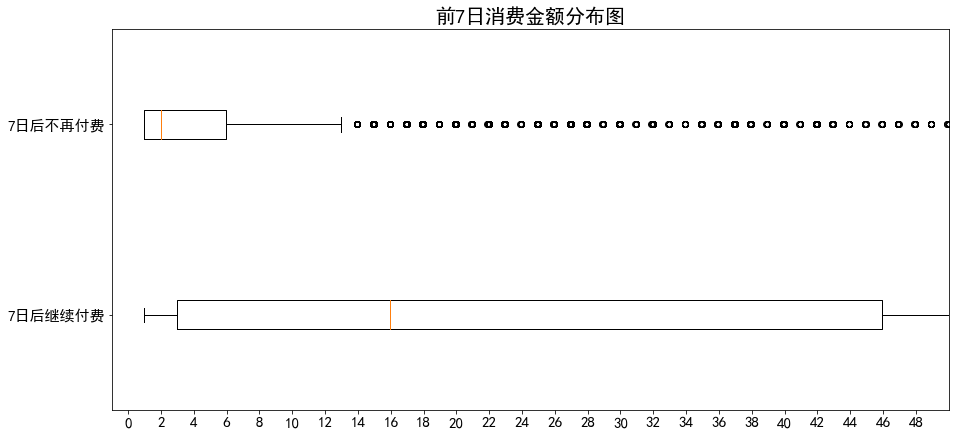

In [38]:
plt.figure(figsize=(15,7))
plt.boxplot([SevenDayPayAmount[SevenDayPayAmount != y][SevenDayPayAmount != 0],SevenDayPayAmount[SevenDayPayAmount == y][SevenDayPayAmount != 0]],labels=["7日后继续付费","7日后不再付费"],vert=False,showmeans=False)
plt.xlim(-1,50)
plt.title('前7日消费金额分布图',fontsize=20.0)
plt.yticks(fontsize=15.0)
plt.xticks(range(0,50,2),fontsize=15.0)
#plt.vlines(6.0,ymin = plt.ylim()[0]+0.1,ymax = plt.ylim()[1]-0.1,colors="red",linestyles="dotted")
plt.show()

 It is not difficult to find that although the range of in-game spending is the same, the distribution of continuing paying users is much to the right, indicating that paying users after 7 days spend more in the first 7 days. 

 - <font color="#dd0000"> **The first possible criterion for judging high-value users: users who spent more than 6 yuan in the first 7 days are more valuable users**</font><br><br>
Based on this speculation, the novice gift package is set at 5-7 yuan, which may clearly identify the user's paying ability. 

 For users who have spent money within 7 days, users who have spent any amount of money have a certain probability of continuing to spend money, and there is also a certain probability that they will no longer spend money, and the two probabilities add up to 1. Give a simple example: 

 Assume that there are 60 people who paid more than n yuan in the first 7 days. Among these 60 people, 20 will continue to make money and 40 will no longer make money. Then we can say that **when a user spends more than n yuan in the first 7 days, the probability of continuing to make money is 20/60 = 33%, and the probability of no longer making money is 40/60 = 66%**. 

According to historical data, the greater the amount of money spent by a user within 7 days, the higher the user's psychological expectations for gold, the greater the possibility of continuing to spend money, and the smaller the possibility of no longer spending money. Based on the numbers in the above example, we should believe that the probability that users who spent n+1 yuan in the first 7 days will continue to spend money is greater than 33%, and the probability of not spending money is less than 66%. **

 As the amount of money spent in the first 7 days increases, the probability of continuing to use money will become larger and larger, and the probability of no longer using money will become smaller and smaller. Therefore, there must be an amount point. When the amount paid by a user in the previous 7 days exceeds this amount point, the possibility of the user continuing to use money is greater than the possibility of no longer spending**. This amount point is suitable for setting up as a novice gift package. Now let’s find out this point. 

<<<U92>>Considering that 50% of subsequent paying users paid 16 yuan or more, we speculate that this amount should be below 16 yuan, so we set the potential amount range to 1-16. 

In [39]:
PotentialPoints = range(1,16)

In [40]:
[*PotentialPoints]

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

In [41]:
for i in PotentialPoints:
    #Retrieve all paying users whose payment amount exceeds i within 7 days
    HigherThanPoint = SevenDayPayAmount[SevenDayPayAmount>=i] 
    #Among these users, the proportion of users who continue to pay
    KeepPaid = len(HigherThanPoint[SevenDayPayAmount != y])/len(HigherThanPoint) 
    # Among these users, the proportion of users who stopped paying is actually 1-KeepPaid
    StopPaid = len(HigherThanPoint[SevenDayPayAmount == y])/len(HigherThanPoint)
    print(i)
    print("{:.3f}%".format(100*KeepPaid))
    print("{:.3f}%".format(100*StopPaid))
    print("{:.3f}%".format(KeepPaid - StopPaid))
    if KeepPaid - StopPaid > 0:
        print("当7日内付费金额大于{:.2f}时，用户继续氪金的可能性比不再氪金的可能性更高！".format(i))
        break

1
37.683%
62.317%
-0.246%
2
43.720%
56.280%
-0.126%
3
45.759%
54.241%
-0.085%
4
46.532%
53.468%
-0.069%
5
48.094%
51.906%
-0.038%
6
50.778%
49.222%
0.016%
当7日内付费金额大于6.00时，用户继续氪金的可能性比不再氪金的可能性更高！


 It is more obvious to use images: 

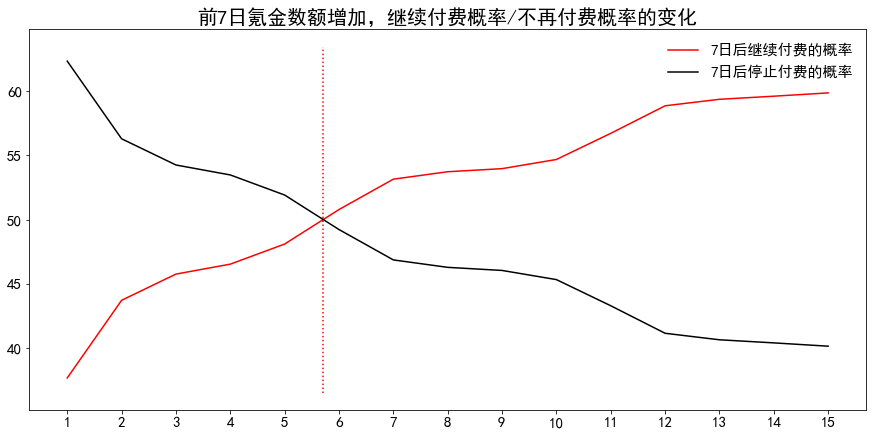

In [42]:
KeepPaidList = []
StopPaidList = []
for i in PotentialPoints:
    #Retrieve all paying users whose payment amount exceeds i within 7 days
    HigherThanPoint = SevenDayPayAmount[SevenDayPayAmount>=i] 
    #Among these users, the proportion of users who continue to pay
    KeepPaid = len(HigherThanPoint[SevenDayPayAmount != y])/len(HigherThanPoint) 
    #Among these users, the proportion of users who stopped paying
    StopPaid = len(HigherThanPoint[SevenDayPayAmount == y])/len(HigherThanPoint)
    KeepPaidList.append(100*KeepPaid)
    StopPaidList.append(100*StopPaid)

plt.figure(figsize=(15,7))
plt.plot(PotentialPoints,KeepPaidList,label="7日后继续付费的概率",color="red")
plt.plot(PotentialPoints,StopPaidList,label="7日后停止付费的概率",color="k")
#plt.xlim(-1,50)
plt.title('前7日氪金数额增加，继续付费概率/不再付费概率的变化',fontsize=20.0)
plt.yticks(fontsize=15.0)
plt.xticks(range(0,16,1),fontsize=15.0)
plt.legend(fontsize = 15.0, frameon = False)
plt.vlines(5.7,ymin = plt.ylim()[0]+0.1,ymax = plt.ylim()[1]-0.1,colors="red",linestyles="dotted")
plt.show()

For users who have paid less than 6 yuan in the first 7 days, regardless of whether they are lost naturally or not, the possibility of making money in the future is less than the possibility of no longer paying. You can set up the game experience to give more "stimulus" to users who pay about 5 yuan, so that they can continue to pay in the future. You can also choose to directly abandon paying users below 6 yuan, maintain the status quo or reduce resource allocation, so that more resources/services can be deployed around users who are more likely to pay. 

> Back to our revenue analysis: 

In [43]:
#Conversion status on 45th
RevenueFocus(y)

付费率：2.010%
付费人数：45988
转化总金额：4102730.110
ARPU：1.793
ARPPU：89.213
前500高氪用户金额占比：51.618%
前1000高氪用户金额占比：64.878%
前5000高氪用户金额占比：89.375%


In [44]:
y.max()

32977.81

In [45]:
#7-day conversion status
RevenueFocus(SevenDayPayAmount)

付费率：1.811%
付费人数：41439
转化总金额：1223326.660
ARPU：0.535
ARPPU：29.521
前500高氪用户金额占比：45.211%
前1000高氪用户金额占比：57.231%
前5000高氪用户金额占比：83.002%


> Let’s look at ARPU and ARPPU data. ARPU is the average income of users of the whole server, and ARPPU is the average income of paying users of the whole server. At present, the ARPU of the whole server is low, but the ARPPU is not bad. This shows that although the number of paying people is not large, the paying ability of big R (big RMB players) is relatively strong. Judging from the proportion of the top 5,000 high-spending users, on the 45th, the top 5,000 in-game spending users in the entire server (z accounted for less than 0.22%) provided 89% of the revenue in the entire server, and the big R’s made a huge contribution. This makes me guess that the in-game spending behavior in "Savage Age" should be more directly related to the player's competitiveness, because many big R players are very fond of strong PK games. Paying can directly make PVP extremely simple. However, the consumption of the highest-spending player in the entire server in a month is only 3w2, which is not a very high number in the field of SLG mobile games. If the game experience is excellent, there should be a lot of room for improvement. The problem of not many paying people can be improved, and the overall business results of the game can be improved to a higher level. 

——————————

<<<U105>>### 3. Exploration of features

#### 3.1 Online duration: Are users losing at a faster than normal rate? 

In [46]:
data.columns

Index(['玩家唯一ID', '玩家注册时间', '木头获取数量', '木头消耗数量', '石头获取数量', '石头消耗数量', '象牙获取数量',
       '象牙消耗数量', '肉获取数量', '肉消耗数量',
       ...
       'PVP次数', '主动发起PVP次数', 'PVP胜利次数', 'PVE次数', '主动发起PVE次数', 'PVE胜利次数',
       '在线时长', '付费金额', '付费次数', '45日付费金额'],
      dtype='object', name='字段解释', length=109)

When analyzing the distribution of revenue and resources, we speculated that users may be losing at an abnormal rate. Generally speaking, the next-day retention rate of any mobile game should be above 50%, and the 7-day retention rate should be around 30%. A successful mobile game needs to achieve a retention rate of about 50% on the 7th day, and "Brutal Age" may not reach the 50% passing rate of next-day retention. Among the features, there is a column of "Online Duration", which is the length of time the user was online in the past 7 days. By judging how long users are online, we can roughly estimate the speed of user churn. 

In [47]:
PlayTime = data.loc[:,"在线时长"]

In [48]:
PlayTime.max()

2049.666667

<<<U108>>The original data does not specify the unit of this feature that measures time, but 7 days is 168 hours, so the unit of this feature should be minutes. The player who played the longest game in the first 7 days played for 2049 minutes, which is 34 hours. He plays for more than 5 hours a day. This is also a figure that hardcore players can achieve. The unit is minutes, which is reasonable. 

In [49]:
pd.set_option("display.float_format", lambda x: "%.3f" % x) #To avoid display problems, set not to display scientific notation
PlayTime.describe()

count   2288007.000
mean         10.207
std          38.959
min           0.000
25%           0.500
50%           1.833
75%           4.833
max        2049.667
Name: 在线时长, dtype: float64

 75% of people played the game for a total of 4.8 minutes or less in the first 7 days. This means that more than 75% of users were dissuaded from the game after just a brief glance at the game. 

In [50]:
PlayTime.describe(percentiles=[0.75,.9,0.95,.99]) # Check the distribution of more than 90%

count   2288007.000
mean         10.207
std          38.959
min           0.000
50%           1.833
75%           4.833
90%          15.000
95%          41.333
99%         183.657
max        2049.667
Name: 在线时长, dtype: float64

<<<U112>>SLG games are naturally filled with many tasks, rewards and plots. Unless the user logs out immediately, they should stay for at least 5 minutes after logging in. New users should stay longer (there is a lot of content to explore and the task list is also very long). If a user is retained and participates in the game the next day after registering for the game, the online time for the two days should be at least 15-20 minutes. 75% of users only played for 4.8 minutes in the first 7 days, and as shown below, 90% of users played for less than 15 minutes in 7 days. It is inferred that only about 10-15% of users still retain the game the next day and play for about 10 minutes a day. Less than 5% of users remain after 7 days. Users are indeed lost in an unusual way, and in this way, the payment rate is difficult to save. 

In [51]:
#Who is this user who played for 2049 minutes? 

In [52]:
 (data["在线时长"] > 2000).sum() #Possible tester, GM

1

In [53]:
data.loc[data["在线时长"] > 2049,:] #69 wood is obtained, 69w meat is obtained

字段解释,玩家唯一ID,玩家注册时间,木头获取数量,木头消耗数量,石头获取数量,石头消耗数量,象牙获取数量,象牙消耗数量,肉获取数量,肉消耗数量,...,PVP次数,主动发起PVP次数,PVP胜利次数,PVE次数,主动发起PVE次数,PVE胜利次数,在线时长,付费金额,付费次数,45日付费金额
488497,645487,2018-03-04 13:43:36,697852.000,300255.000,0.000,0.000,6000.000,0.000,690379.000,196602.000,...,5,0,0,2,2,2,2049.667,0.000,0,0.000


In [54]:
data.loc[data["在线时长"] > 1500,:] #Compared with the duration, deeper participation in the game may be more relevant to in-game spending

字段解释,玩家唯一ID,玩家注册时间,木头获取数量,木头消耗数量,石头获取数量,石头消耗数量,象牙获取数量,象牙消耗数量,肉获取数量,肉消耗数量,...,PVP次数,主动发起PVP次数,PVP胜利次数,PVE次数,主动发起PVE次数,PVE胜利次数,在线时长,付费金额,付费次数,45日付费金额
488497,645487,2018-03-04 13:43:36,697852.000,300255.000,0.000,0.000,6000.000,0.000,690379.000,196602.000,...,5,0,0,2,2,2,2049.667,0.000,0,0.000
1263615,1579134,2018-03-05 11:04:18,15722711.000,15269965.000,8895972.000,7952637.000,4554662.000,3025143.000,23321313.000,21071538.000,...,48,25,11,100,100,86,1674.667,2.980,2,514.680


In [55]:
# Try to find the gaming time of paying users in the past 7 days

In [56]:
PaidPlayTime = data.loc[data["付费金额"] != 0,"在线时长"]

In [57]:
PaidPlayTime.describe().T #Only less than 25% of users spend less than half an hour online, and they spend significantly more time playing games than non-money users

count   41439.000
mean      140.188
std       149.973
min         0.000
25%        33.000
50%        88.833
75%       194.667
max      1674.667
Name: 在线时长, dtype: float64

In [58]:
# Among the players who spent less than 1 minute online with their eyes closed, 40 people spent ¥0.99

In [59]:
data.loc[data["在线时长"]<=1,"付费金额"].value_counts()

0.000     896061
0.990         51
9.990          4
36.960         3
5.980          3
4.990          3
99.990         2
56.950         2
19.990         1
26.970         1
25.970         1
6.980          1
49.990         1
1.990          1
Name: 付费金额, dtype: int64

In [60]:
# Users who have been online for a long time are not necessarily high-spending players
#Users who have been online for a short time may not be completely uninterested
#How to judge user value based on online time? 

In [61]:
#The amount of in-game spending contributed by players who have been online for a short time
for playtime in [1,5,15,20,25,30]:
    
    MeanPay45 = data.loc[data["在线时长"]<playtime,"45日付费金额"].mean()
    TotalPay45 = data.loc[data["在线时长"]<playtime,"45日付费金额"].sum()
    MeanPay7 = data.loc[data["在线时长"]<playtime,"付费金额"].mean()
    TotalPay7 = data.loc[data["在线时长"]<playtime,"付费金额"].sum()
    
    print("一周在线时长不足{}分钟".format(playtime))
    print("\t45日平均消费额为{:.3f}元，45日总消费额为{:.3f}元".format(MeanPay45,TotalPay45))
    print("\t7日平均消费额为{:.3f}元，7日总消费额为{:.3f}元".format(MeanPay7,TotalPay7))
    print("\t7日氪金占比{:.3f}%，45日氪金占比{:.3f}%".format(100*TotalPay7/(data["付费金额"].sum())
                                                  ,100*TotalPay45/(data["45日付费金额"].sum())))

一周在线时长不足1分钟
	45日平均消费额为0.022元，45日总消费额为18323.490元
	7日平均消费额为0.001元，7日总消费额为574.180元
	7日氪金占比0.047%，45日氪金占比0.447%
一周在线时长不足5分钟
	45日平均消费额为0.019元，45日总消费额为32572.700元
	7日平均消费额为0.003元，7日总消费额为4519.280元
	7日氪金占比0.369%，45日氪金占比0.794%
一周在线时长不足15分钟
	45日平均消费额为0.028元，45日总消费额为57753.190元
	7日平均消费额为0.009元，7日总消费额为18428.260元
	7日氪金占比1.506%，45日氪金占比1.408%
一周在线时长不足20分钟
	45日平均消费额为0.038元，45日总消费额为79124.920元
	7日平均消费额为0.012元，7日总消费额为25904.310元
	7日氪金占比2.118%，45日氪金占比1.929%
一周在线时长不足25分钟
	45日平均消费额为0.044元，45日总消费额为94650.110元
	7日平均消费额为0.016元，7日总消费额为34217.390元
	7日氪金占比2.797%，45日氪金占比2.307%
一周在线时长不足30分钟
	45日平均消费额为0.050元，45日总消费额为107763.140元
	7日平均消费额为0.019元，7日总消费额为40862.200元
	7日氪金占比3.340%，45日氪金占比2.627%


 It is not difficult to find that players who have been online for a short time contribute a small amount of in-game spending. When modeling 2 million people, we can ignore some users who have been online for a short time. Here, we can judge users who are online for less than 15 or 20 minutes a week as low-value users. 

In [62]:
data["在线时长"].sort_values(ascending=False)[:2288] #7-day online time of the top 0.1% of users

488497    2049.667
1263615   1674.667
882241    1482.000
1558221   1452.333
1335561   1452.333
            ...   
527722     504.500
2065723    504.333
1815137    504.333
1257763    504.333
2145496    504.333
Name: 在线时长, Length: 2288, dtype: float64

In [63]:
#The amount of in-game spending contributed by players who have been online for a long time
for playtime in [500,600,700,800,900,1000,1200]:
    
    MeanPay45 = data.loc[data["在线时长"]>=playtime,"45日付费金额"].mean()
    TotalPay45 = data.loc[data["在线时长"]>=playtime,"45日付费金额"].sum()
    MeanPay7 = data.loc[data["在线时长"]>=playtime,"付费金额"].mean()
    TotalPay7 = data.loc[data["在线时长"]>=playtime,"付费金额"].sum()
    
    print("一周在线时长超过{}分钟".format(playtime))
    print("\t45日平均消费额为{:.3f}元，45日总消费额为{:.3f}元".format(MeanPay45,TotalPay45))
    print("\t7日平均消费额为{:.3f}元，7日总消费额为{:.3f}元".format(MeanPay7,TotalPay7))
    print("\t7日氪金占比{:.3f}%，45日氪金占比{:.3f}%".format(100*TotalPay7/(data["付费金额"].sum())
                                                  ,100*TotalPay45/(data["45日付费金额"].sum())))

一周在线时长超过500分钟
	45日平均消费额为377.113元，45日总消费额为885839.060元
	7日平均消费额为110.492元，7日总消费额为259544.740元
	7日氪金占比21.216%，45日氪金占比21.591%
一周在线时长超过600分钟
	45日平均消费额为437.753元，45日总消费额为515673.070元
	7日平均消费额为130.699元，7日总消费额为153963.300元
	7日氪金占比12.586%，45日氪金占比12.569%
一周在线时长超过700分钟
	45日平均消费额为427.776元，45日总消费额为272921.300元
	7日平均消费额为120.904元，7日总消费额为77136.600元
	7日氪金占比6.305%，45日氪金占比6.652%
一周在线时长超过800分钟
	45日平均消费额为359.040元，45日总消费额为113815.780元
	7日平均消费额为104.344元，7日总消费额为33076.950元
	7日氪金占比2.704%，45日氪金占比2.774%
一周在线时长超过900分钟
	45日平均消费额为218.907元，45日总消费额为36557.400元
	7日平均消费额为43.819元，7日总消费额为7317.770元
	7日氪金占比0.598%，45日氪金占比0.891%
一周在线时长超过1000分钟
	45日平均消费额为139.194元，45日总消费额为12109.910元
	7日平均消费额为40.055元，7日总消费额为3484.820元
	7日氪金占比0.285%，45日氪金占比0.295%
一周在线时长超过1200分钟
	45日平均消费额为25.492元，45日总消费额为637.300元
	7日平均消费额为2.869元，7日总消费额为71.730元
	7日氪金占比0.006%，45日氪金占比0.016%


Although many users are deeply involved in the game, they are "not good at spending money", so users who are overly enthusiastic are not high-value users. We can stipulate that users who are online for more than 800 minutes a week are low-value users (at the in-game spending level). Similarly, paying users generally dominate resources, but users with a lot of resources are not necessarily paying users. 

In [64]:
data.loc[data["付费金额"] != 0,"木头获取数量"].describe() #paying user station is absolutely dominant in terms of resource volume

count        41439.000
mean      10712783.554
std       34752584.812
min              0.000
25%        2132829.500
50%        5267091.000
75%       10249321.000
max     1239962311.000
Name: 木头获取数量, dtype: float64

In [65]:
data.loc[data["付费金额"] == 0,"木头获取数量"].describe()

count     2246568.000
mean       265084.447
std        887773.641
min             0.000
25%             0.000
50%         40088.000
75%        144657.000
max     158249380.000
Name: 木头获取数量, dtype: float64

In [66]:
data[data["木头获取数量"] == 158249380] #Abnormal user, very awesome user

字段解释,玩家唯一ID,玩家注册时间,木头获取数量,木头消耗数量,石头获取数量,石头消耗数量,象牙获取数量,象牙消耗数量,肉获取数量,肉消耗数量,...,PVP次数,主动发起PVP次数,PVP胜利次数,PVE次数,主动发起PVE次数,PVE胜利次数,在线时长,付费金额,付费次数,45日付费金额
2046401,2907550,2018-03-04 14:41:57,158249380.000,157202081.000,129870402.000,129357887.000,3000.000,0.000,69427801.000,68360181.000,...,282,0,0,2,1,1,125.000,0.000,0,0.000


 It is not difficult to find that users who have many resources but have not paid within 7 days are low-value users (at the in-game spending level). 

——————————

#### 3.2 Distribution and Skewness: Is the game unfriendly to novices? Is the difficulty setting for resource acquisition reasonable? 

 During simple data exploration, we used .describe() to explore the distribution of features, and found that a large number of features are severely left-skewed (that is, most of the values ​​are concentrated on the left, and the peak of the distribution is severely left-skewed). 

In [67]:
#pd.set_option("display.max_rows",120) #To avoid display problems, set the maximum number of rows
data.describe().T

,count,mean,std,min,25%,50%,75%,max
字段解释,,,,,,,,
玩家唯一ID,2288007.000,1529543.498,939939.279,1.000,749992.500,1419095.000,2299006.500,3190530.000
木头获取数量,2288007.000,454306.859,4958667.146,0.000,0.000,42038.000,153118.000,1239962311.000
木头消耗数量,2288007.000,369843.252,3737720.038,0.000,0.000,9830.000,98557.000,799587506.000
石头获取数量,2288007.000,189778.774,4670619.517,0.000,0.000,0.000,0.000,1214869437.000
石头消耗数量,2288007.000,137607.363,3370166.356,0.000,0.000,0.000,0.000,796237770.000
...,...,...,...,...,...,...,...,...
PVE胜利次数,2288007.000,2.557,11.847,0.000,0.000,0.000,1.000,488.000
在线时长,2288007.000,10.207,38.959,0.000,0.500,1.833,4.833,2049.667
付费金额,2288007.000,0.535,22.638,0.000,0.000,0.000,0.000,7457.950


- **The left skew of the data shows that there are fewer people with a lot of resources in the game, because compared to the middle line, most people are closer to the origin in terms of resources/levels**. 

**If all users are retained after 7 days, the resource data distribution should be close to the normal distribution**. Now we already know that users are severely lost in the first 7 days, and the resource distribution will be left skewed and reasonable, but why are users lost so seriously? There may be problems starting from the traffic end (for example, it is placed on an inappropriate traffic channel), there may be problems with the advertisements placed (for example, it makes users mistake it for other types of games), or it may be due to insufficient game art and low appeal (under the premise that 75% of users are persuaded to leave after just one glance, there is reason to believe that there are major problems with game art and smoothness). 

In addition to the above reasons, the massive loss of users may also be caused by the game being unfriendly to novices or the balance of the game being seriously affected by in-game spending. If it is difficult to obtain resources in the game, for example, most resources require a long time or gold to accumulate (this may be a strategy to stimulate gold: it is not user-friendly at the novice stage, and the game is difficult to get started), and most players cannot get enough stimulation and sense of gain within 10 to 15 minutes, then the possibility of losing users within half an hour is very high. We can try to observe the average game time of several resource levels to judge whether the resources in the game are difficult to obtain: 

In [68]:
data["木头获取数量"].describe()

count      2288007.000
mean        454306.859
std        4958667.146
min              0.000
25%              0.000
50%          42038.000
75%         153118.000
max     1239962311.000
Name: 木头获取数量, dtype: float64

In [69]:
data.loc[data["木头获取数量"] > 1239962310,"在线时长"] # The online time is about 10 hours, that is, if you play for more than 1 hour a day, you can get over 100 million wood resources in a week

1423324   697.333
Name: 在线时长, dtype: float64

In [70]:
data.loc[data["木头获取数量"] == 153118,"在线时长"].mean() #On average, you can get 15w wood in about 3.75 minutes online

3.75

In [71]:
data.loc[data["木头获取数量"] == 42038,"在线时长"].mean() #On average, you can get 4w2 wood in 1 minute online

1.2527109844413018

 Judging from the results, at least wood resources are not difficult to obtain at all, but rather easy to come by. In the mobile game world, games that can easily have millions of resources or hundreds of millions of resources are generally not very high-end.

Are other resources very difficult to obtain? With the existing data, we can analyze the rationality of the difficulty classification of resource acquisition in the game by analyzing the resource inventory. 

The distribution of resources itself can aid in analysis. Due to the amount of data, we cannot plot the distribution of all features, but we can calculate the skewness and kurtosis of all features.

> 1. The median value of skewness is 0. Positive skewness indicates that the distribution is skewed to the left, and negative skewness indicates that the distribution is skewed to the right.
> 2. The larger the skewness value, the greater the distribution shift. For example, when the skewness is much greater than 0, it means that most of the data is concentrated near the origin.
> 3. The kurtosis of the normal distribution is 3 (approximately equal to 0 compared with huge kurtosis). A kurtosis greater than 3 indicates a steep mountain peak, and a kurtosis less than 3 indicates a gentle mountain peak.
> 4. The larger the kurtosis value, the more uneven the distribution of the data and the more concentrated it is on certain values. 

![](https://skojiangdoc.oss-cn-beijing.aliyuncs.com/micro_class/sklearncase/%E5%B3%B0%E5%BA%A6%E4%B8%8E%E5%81%8F%E5%BA%A6.%20PNG.PNG)

For game data, skewness and kurtosis measure something similar: skewness describes the situation where the distribution is symmetrical, and kurtosis describes the situation where the distribution is concentrated at a few points. Both huge positive skewness and huge kurtosis point to a state where "most players can only collect few resources/or no resources." Combined with the average value of a single resource, we can further determine the true situation of resource acquisition. Here, we only measure resource/skill levels, not factors related to battles such as the number of PVPs. 

In [72]:
data.columns

Index(['玩家唯一ID', '玩家注册时间', '木头获取数量', '木头消耗数量', '石头获取数量', '石头消耗数量', '象牙获取数量',
       '象牙消耗数量', '肉获取数量', '肉消耗数量',
       ...
       'PVP次数', '主动发起PVP次数', 'PVP胜利次数', 'PVE次数', '主动发起PVE次数', 'PVE胜利次数',
       '在线时长', '付费金额', '付费次数', '45日付费金额'],
      dtype='object', name='字段解释', length=109)

In [73]:
resource = data.iloc[:,2:-10]

In [74]:
resource.columns

Index(['木头获取数量', '木头消耗数量', '石头获取数量', '石头消耗数量', '象牙获取数量', '象牙消耗数量', '肉获取数量',
       '肉消耗数量', '魔法获取数量', '魔法消耗数量', '勇士招募数量', '勇士损失数量', '驯兽师招募数量', '驯兽师损失数量',
       '萨满招募数量', '萨满损失数量', '勇士伤兵产生数量', '勇士伤兵恢复数量', '驯兽师伤兵产生数量', '驯兽师伤兵恢复数量',
       '萨满伤兵产生数量', '萨满伤兵恢复数量', '通用加速获取数量', '通用加速使用数量', '建筑加速获取数量', '建筑加速使用数量',
       '科研加速获取数量', '科研加速使用数量', '训练加速获取数量', '训练加速使用数量', '治疗加速获取数量', '治疗加速使用数量',
       '建筑：士兵小屋等级', '建筑：治疗小井等级', '建筑：要塞等级', '建筑：据点传送门等级', '建筑：兵营等级',
       '建筑：治疗之泉等级', '建筑：智慧神庙等级', '建筑：联盟大厅等级', '建筑：仓库等级', '建筑：瞭望塔等级',
       '建筑：魔法幸运树等级', '建筑：战争大厅等级', '建筑：联盟货车等级', '建筑：占卜台等级', '建筑：祭坛等级',
       '建筑：冒险传送门等级', '科研：侦查等级', '科研：训练速度等级', '科研：守护者', '科研：巨兽驯兽师', '科研：吟唱者',
       '科研：勇士攻击', '科研：驯兽师攻击', '科研：萨满攻击', '科研：战斗大师', '科研：高阶巨兽骑兵', '科研：图腾大师',
       '科研：部队防御', '科研：勇士防御', '科研：驯兽师防御', '科研：萨满防御', '科研：勇士生命', '科研：驯兽师生命',
       '科研：萨满生命', '科研：狂战士', '科研：龙骑兵', '科研：神谕者', '科研：部队攻击', '科研：建造速度',
       '科研：资源保护', '科研：部队消耗', '科研：木材生产', '科研：石头生产', '科研：象牙生产', '科研：肉类生产',
       '科研：木材采集', '科研：石头采集', '科研

In [75]:
sak = pd.DataFrame()
for idx,ColName in enumerate(resource.columns):
    sak.loc[idx,"特征"] = ColName
    column = data.loc[:,ColName]
    sak.loc[idx,"偏度"] = column.skew() #skewness
    sak.loc[idx,"峰度"] = column.kurt() #Kurtosis
    sak.loc[idx,"均值"] = column.mean() #Mean

In [76]:
sak.head()

,特征,偏度,峰度,均值
0,木头获取数量,100.635,15449.582,454306.859
1,木头消耗数量,86.310,11367.448,369843.252
2,石头获取数量,113.794,18489.107,189778.774
3,石头消耗数量,105.043,15515.988,137607.363
4,象牙获取数量,112.636,17682.030,80756.230


In [77]:
pd.set_option("display.max_rows",120) #To avoid display problems, set the maximum number of lines 
sak.sort_values("偏度")

,特征,偏度,峰度,均值
34,建筑：要塞等级,1.229,0.970,2.098
35,建筑：据点传送门等级,1.383,1.477,1.764
32,建筑：士兵小屋等级,1.878,3.314,1.306
42,建筑：魔法幸运树等级,2.050,3.388,1.146
36,建筑：兵营等级,2.114,4.327,1.284
33,建筑：治疗小井等级,2.183,4.567,1.027
41,建筑：瞭望塔等级,2.409,5.619,0.913
37,建筑：治疗之泉等级,2.429,5.627,0.924
40,建筑：仓库等级,2.472,5.525,0.934
38,建筑：智慧神庙等级,2.495,5.893,0.969


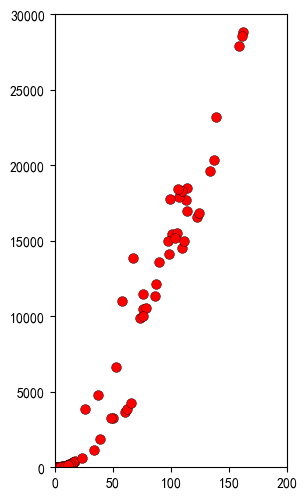

In [78]:
#Kurtosis and skewness seem to show a highly consistent trend - when the skewness is large, the kurtosis also tends to be large. We can draw a graph to take a look
plt.figure(figsize=(3,6),dpi=100)
plt.scatter("偏度","峰度", data = sak
           ,s = 50
           ,c = "red"
           ,edgecolors = "k"
           ,linewidth = 0.3);
plt.xlim(0, 200) #Control the range of horizontal and vertical coordinates
plt.ylim(0, 30000)
plt.show()

 Therefore, we can only consider skewness and mean, and no longer consider kurtosis. **If we can draw a scatter plot with the abscissa as skewness and the ordinate as mean, we can summarize the relationship between skewness and mean, and summarize the setting types of different resources/different levels, so as to judge whether the difficulty of obtaining various resources in the game is reasonable**. Before drawing, we can roughly judge that the mean and skewness should be able to separate the types of features in the following way: 

![](https://skojiangdoc.oss-cn-beijing.aliyuncs.com/micro_class/sklearncase/%E5%9B%9B%E5%A4%A7%E5%88%86%E7%B1%BB2.PNG)

> - Category A **High mean, low skewness**: Users have a relatively even distribution of this resource, and everyone has a lot of this resource. This type of resource is the easiest to obtain 

![](https://skojiangdoc.oss-cn-beijing.aliyuncs.com/micro_class/sklearncase/A.PNG)

> - Category B **High mean and high skewness**: The resources owned by users are unevenly distributed, and a small number of players control a huge amount of resources (the long tail will be very, very long), which raises the mean. Such resources may be in-game spending resources, or they may be resources that can only be obtained by breaking the bank 

![](https://skojiangdoc.oss-cn-beijing.aliyuncs.com/micro_class/sklearncase/B.PNG)

> - Category C **Low mean and low skewness**: Users have a relatively even distribution of this resource, but no one has this resource. This type of resource may take time to accumulate. As the server opening time becomes longer, this type of resource should gradually turn into other types of resources 

![](https://skojiangdoc.oss-cn-beijing.aliyuncs.com/micro_class/sklearncase/C.PNG)

> - Category D **Low mean, high skewness**: The resource owned by users is unevenly distributed. Only a small number of players master the resource, but the total amount they master is not large. Such resources are inherently scarce and cannot be obtained with in-game spending (for example, resources that can only be obtained by triggering a specific plot/reaching a specific achievement), and only a few people can own them 

![](https://skojiangdoc.oss-cn-beijing.aliyuncs.com/micro_class/sklearncase/D.PNG)

In a healthy game, type A resources should be the most abundant. These resources determine the extent to which the script can be advanced and determine the game experience of most players. Type B resources are mainly used for payment and are the main source of income, but may seriously damage the balance of the game. Type D resources are mainly used to increase the fun and fairness of the game and should be the least. A game must have enough Type A resources to be considered friendly to novices. As long as we draw a scatter plot, the distribution of the four types of resources will be clear. 

In [79]:
print(sak["偏度"].max())
print(sak["偏度"].min())
print(sak["均值"].max())
print(sak["均值"].min())

1446.870493367135
1.229280867942684
585515.5045294879
2.185307999494757e-06


>The difficulty now is that both skewness and mean include some extremely large outliers, so the data range is very high, and most of the data points are concentrated near smaller values. When drawing such data, it is easy for the following situations to occur: 

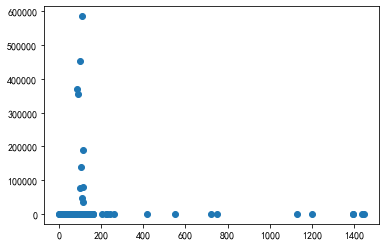

In [80]:
plt.scatter("偏度","均值", data = sak)
plt.show() #All data points are piled together, no pattern can be seen

 To solve this problem, let’s draw three images with different ordinate values——

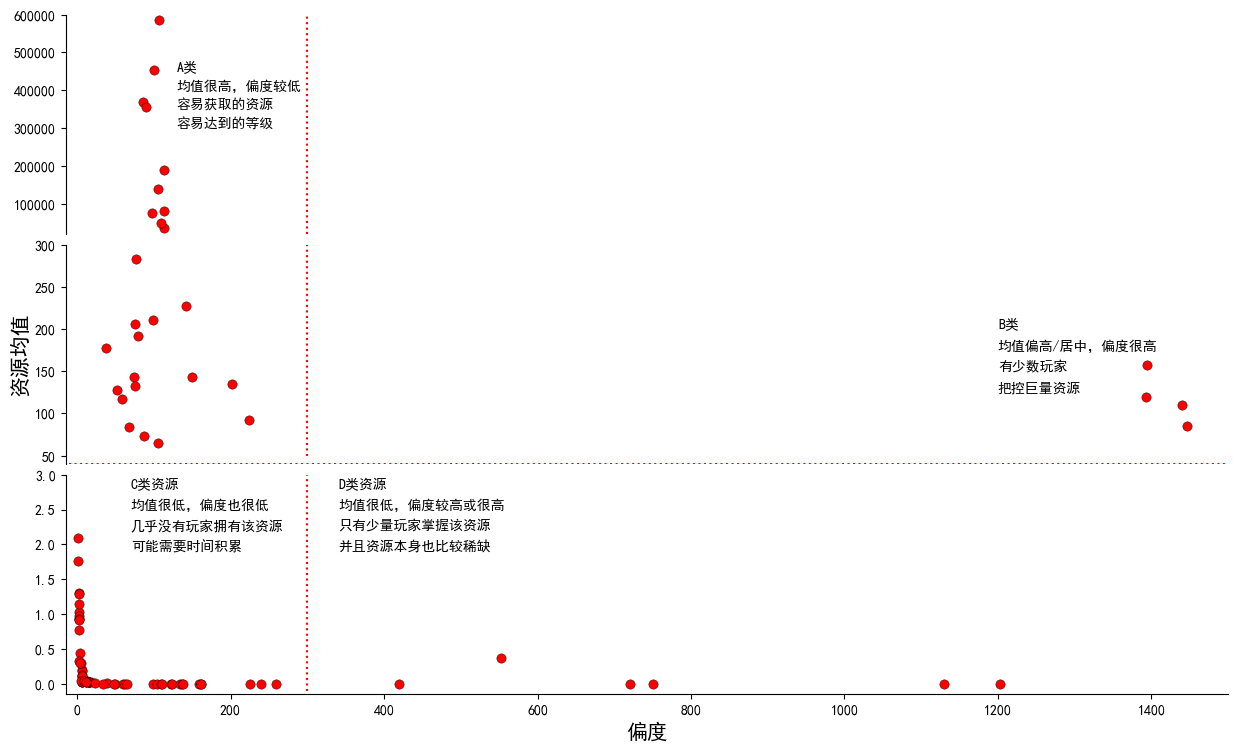

In [81]:
plt.figure(figsize=(15,9),dpi=100)
#Draw images with three different coordinate axes

#上
plt.subplot(311)
plt.scatter("偏度","均值", data = sak
           ,s = 45
           ,c = "red"
           ,edgecolors = "k"
           ,linewidth = 0.3);
plt.xlim(-15, 1500) #Control the range of horizontal and vertical coordinates
plt.ylim(20000, 600000)
plt.vlines(300, 20000, 600000,colors="red",linestyles="dotted")
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
plt.yticks(fontsize=10)
plt.text(130,450000,s="A类")
plt.text(130,400000,s="均值很高，偏度较低")
plt.text(130,350000,s="容易获取的资源")
plt.text(130,300000,s="容易达到的等级")
plt.xticks([])

#中
plt.subplot(312)
plt.scatter("偏度","均值", data = sak
           ,s = 45
           ,c = "red"
           ,edgecolors = "k"
           ,linewidth = 0.3);
plt.xlim(-15, 1500)
plt.ylim(40, 300)
plt.vlines(300, 50, 300,colors="red",linestyles="dotted")
plt.hlines(40,-10, 1500,colors="red",linestyles="dotted")
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
plt.yticks(fontsize=10)
plt.ylabel("资源均值", fontsize=15)
plt.text(1200,200,s="B类")
plt.text(1200,175,s="均值偏高/居中，偏度很高")
plt.text(1200,150,s="有少数玩家")
plt.text(1200,125,s="把控巨量资源")
plt.xticks([])

#下
plt.subplot(313)
plt.scatter("偏度","均值", data = sak
           ,s = 45
           ,c = "red"
           ,edgecolors = "k"
           ,linewidth = 0.3);
plt.xlim(-15, 1500)
plt.ylim(-0.15, 3)
plt.vlines(300, -0.1, 5,colors="red",linestyles="dotted")
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel("偏度", fontsize=15)
plt.yticks(fontsize=10)
plt.text(70,2.8,s="C类资源")
plt.text(70,2.5,s="均值很低，偏度也很低")
plt.text(70,2.2,s="几乎没有玩家拥有该资源")
plt.text(70,1.9,s="可能需要时间积累")
plt.text(340,2.8,s="D类资源")
plt.text(340,2.5,s="均值很低，偏度较高或很高")
plt.text(340,2.2,s="只有少量玩家掌握该资源")
plt.text(340,1.9,s="并且资源本身也比较稀缺")
plt.subplots_adjust(hspace=0.05)
plt.show()

 Let’s check what the four types of resources are and whether the quantity is reasonable: 

In [82]:
#A type
A = sak.loc[sak["均值"] > 3,:].loc[sak["偏度"]<300,:]

In [83]:
A

,特征,偏度,峰度,均值
0,木头获取数量,100.635,15449.582,454306.859
1,木头消耗数量,86.310,11367.448,369843.252
2,石头获取数量,113.794,18489.107,189778.774
3,石头消耗数量,105.043,15515.988,137607.363
4,象牙获取数量,112.636,17682.030,80756.230
5,象牙消耗数量,113.405,16974.594,36131.699
6,肉获取数量,106.645,17907.029,585515.505
7,肉消耗数量,89.403,13600.967,354810.206
8,魔法获取数量,97.762,14958.235,75389.535
9,魔法消耗数量,109.334,18322.774,47253.994


In [84]:
A.shape

(27, 4)

In [85]:
#B class
sak.loc[sak["均值"] > 3,:].loc[sak["偏度"]>300,:]

,特征,偏度,峰度,均值
14,萨满招募数量,1393.339,2048745.112,119.543
15,萨满损失数量,1394.118,2050265.411,156.853
20,萨满伤兵产生数量,1439.747,2141351.573,110.431
21,萨满伤兵恢复数量,1446.870,2155525.025,84.763


In [86]:
#C category - a large number of untapped resources & a large number of levels - resources that are relatively easy to obtain
sak.loc[sak["均值"] < 3,:].loc[sak["偏度"]<300,:].shape[0]

60

In [87]:
#D Category - Extremely scarce resources
sak.loc[sak["均值"] < 3,:].loc[sak["偏度"]>300,:].shape[0]

6

In [88]:
data.loc[:,A["特征"]].describe().T

,count,mean,std,min,25%,50%,75%,max
字段解释,,,,,,,,
木头获取数量,2288007.000,454306.859,4958667.146,0.000,0.000,42038.000,153118.000,1239962311.000
木头消耗数量,2288007.000,369843.252,3737720.038,0.000,0.000,9830.000,98557.000,799587506.000
石头获取数量,2288007.000,189778.774,4670619.517,0.000,0.000,0.000,0.000,1214869437.000
石头消耗数量,2288007.000,137607.363,3370166.356,0.000,0.000,0.000,0.000,796237770.000
象牙获取数量,2288007.000,80756.230,2220540.322,0.000,0.000,0.000,0.000,574496104.000
象牙消耗数量,2288007.000,36131.699,1782498.688,0.000,0.000,0.000,0.000,448197157.000
肉获取数量,2288007.000,585515.505,5868629.397,0.000,0.000,34587.000,136001.000,1470643810.000
肉消耗数量,2288007.000,354810.206,3400632.455,0.000,0.000,6470.000,66054.000,888953714.000
魔法获取数量,2288007.000,75389.535,966289.236,0.000,0.000,0.000,0.000,263722820.000


From the analysis results, the proportion of various resources is actually quite reasonable. Assuming that a game only wants to serve players who earn money, there will be a lot of B-type resources, and the channels for obtaining a large number of A-type resources will also turn to the direction of in-game spending. However, "Savage Age" obviously does not have such a design. In the early stage of the game, only the concentrated resources and skills related to the shaman type require in-game spending. This shows that the game is still committed to providing a better experience for ordinary players, so most users should not quit the game because the beginner level is too difficult and the plot cannot be advanced. However, the availability of various types of resources is actually very different. Basic resources can easily reach millions or even hundreds of millions, which may make users feel seriously inadequate. From the perspective of the distribution of Class A resources, only the two most basic resources, wood and meat, are relatively normal in distribution, while other resources are severely left-skewed, ** indicating that "low retention rate" is the reason, and "abnormal resource data" is the result**. The most likely situation is that the product logic is not smooth, the sense of gain is insufficient, the art is insufficient, system bugs (such as crazy crashes, etc.), or the strong sense of making money/not being high-end makes most users lose it on the first day. 

——————————

#### 3. Balance impact: in-game spending and combat advantage

If the game is not difficult for novices to get started, is it the setting of the combat power system that makes non-paying players feel unfriendly? Overly powerful characters, overly powerful skills and props may affect the balance of the game. Balance, a complex indicator, can actually be considered from many aspects. Unfortunately, with the existing data, the only thing we can consider is the winning rate. We can analyze the difference in combat power between users who spend money and users who do not spend money to judge the impact of money on game balance. 

In [94]:
data.columns.tolist()

['玩家唯一ID',
 '玩家注册时间',
 '木头获取数量',
 '木头消耗数量',
 '石头获取数量',
 '石头消耗数量',
 '象牙获取数量',
 '象牙消耗数量',
 '肉获取数量',
 '肉消耗数量',
 '魔法获取数量',
 '魔法消耗数量',
 '勇士招募数量',
 '勇士损失数量',
 '驯兽师招募数量',
 '驯兽师损失数量',
 '萨满招募数量',
 '萨满损失数量',
 '勇士伤兵产生数量',
 '勇士伤兵恢复数量',
 '驯兽师伤兵产生数量',
 '驯兽师伤兵恢复数量',
 '萨满伤兵产生数量',
 '萨满伤兵恢复数量',
 '通用加速获取数量',
 '通用加速使用数量',
 '建筑加速获取数量',
 '建筑加速使用数量',
 '科研加速获取数量',
 '科研加速使用数量',
 '训练加速获取数量',
 '训练加速使用数量',
 '治疗加速获取数量',
 '治疗加速使用数量',
 '建筑：士兵小屋等级',
 '建筑：治疗小井等级',
 '建筑：要塞等级',
 '建筑：据点传送门等级',
 '建筑：兵营等级',
 '建筑：治疗之泉等级',
 '建筑：智慧神庙等级',
 '建筑：联盟大厅等级',
 '建筑：仓库等级',
 '建筑：瞭望塔等级',
 '建筑：魔法幸运树等级',
 '建筑：战争大厅等级',
 '建筑：联盟货车等级',
 '建筑：占卜台等级',
 '建筑：祭坛等级',
 '建筑：冒险传送门等级',
 '科研：侦查等级',
 '科研：训练速度等级',
 '科研：守护者',
 '科研：巨兽驯兽师',
 '科研：吟唱者',
 '科研：勇士攻击',
 '科研：驯兽师攻击',
 '科研：萨满攻击',
 '科研：战斗大师',
 '科研：高阶巨兽骑兵',
 '科研：图腾大师',
 '科研：部队防御',
 '科研：勇士防御',
 '科研：驯兽师防御',
 '科研：萨满防御',
 '科研：勇士生命',
 '科研：驯兽师生命',
 '科研：萨满生命',
 '科研：狂战士',
 '科研：龙骑兵',
 '科研：神谕者',
 '科研：部队攻击',
 '科研：建造速度',
 '科研：资源保护',
 '科研：部队消耗',
 '科研：木材生产',
 '科研：石头生产',
 '科研：象牙生产',
 '科研：肉类生产',
 '科研：木材采集',
 '科研：石头采集',


In [95]:
 #7 The number of PVP per capita of players who earn gold on 7 days - whether players who earn gold are keen on fighting 
data[data["付费金额"] !=0]["PVP次数"].mean()

25.193802939260117

In [22]:
#7-Day PVP Win Rate Distribution of Paying Players
(data[data["付费金额"] !=0]["PVP胜利次数"]/data[data["付费金额"] !=0]["PVP次数"]).describe()

count    35755.000000
mean         0.532767
std          0.359898
min          0.000000
25%          0.200000
50%          0.600000
75%          0.864865
max          1.000000
dtype: float64

 It can be seen that the per capita PVP win rate is 53.27%, which is an acceptable number for paying players of mobile games, but it is not a particularly big advantage. The count number is less than the total number of paying players, which means that some players have 0 PVP times. To avoid the error of dividing by 0, these players are eliminated. The proportion of players who do not participate in PVP is: 

In [37]:
1 - 35755/data[data["付费金额"] !=0].shape[0] #13% of paying players never play PVP

0.1371654721397717

In [99]:
#PVP times per capita for players who do not spend money
data[data["付费金额"] == 0]["PVP次数"].mean()

1.723228497868749

In [100]:
# PVP winning rate distribution of players who do not spend money
(data[data["付费金额"] == 0]["PVP胜利次数"]/data[data["付费金额"] ==0]["PVP次数"]).describe()

count   539947.000
mean         0.254
std          0.355
min          0.000
25%          0.000
50%          0.000
75%          0.500
max          1.000
dtype: float64

For non-paying players, the average PVP win rate is only 25%, and 75% of people have an average win rate of less than 50%. This condition is indeed quite harsh for non-paying players. Similarly, some players who do not spend money have 0 PVP times, that is, they have not participated even once. Let’s look at the proportion of people participating in PVP among players who don’t spend money: 

In [38]:
1 - 539947/data[data["付费金额"] ==0].shape[0]

0.7596569522934539

<<<U178>>This ratio is extremely high. Of course, many of the users who do not spend money may have been lost users, so of course they will not participate in PVP battles. 

In [101]:
#paying players will be more militant? Are non-paying players more Buddhist? 
(data[data["付费金额"] !=0]["主动发起PVP次数"]/data[data["付费金额"] !=0]["PVP次数"]).describe()

count   35755.000
mean        0.452
std         0.357
min         0.000
25%         0.000
50%         0.500
75%         0.783
max         1.000
dtype: float64

For paying players, an average of 45% of PVP battles are initiated by them. 

In [102]:
(data[data["付费金额"] ==0]["主动发起PVP次数"]/data[data["付费金额"] ==0]["PVP次数"]).describe()

count   539947.000
mean         0.262
std          0.365
min          0.000
25%          0.000
50%          0.000
75%          0.500
max          1.000
dtype: float64

 Non-paying players actively initiate battles 26% of the time, but most of the time 75% of them do not initiate battles. 

If paying players have an absolute advantage in PVP, is the same situation true in PVE? 

In [103]:
#paying player PVE winning rate distribution
(data[data["付费金额"] !=0]["PVE胜利次数"]/data[data["付费金额"] !=0]["PVE次数"]).describe()

count   37389.000
mean        0.885
std         0.141
min         0.000
25%         0.840
50%         0.926
75%         0.988
max         1.000
dtype: float64

In [104]:
# PVE winning rate distribution of players who do not spend money
(data[data["付费金额"] ==0]["PVE胜利次数"]/data[data["付费金额"] ==0]["PVE次数"]).describe()

count   703148.000
mean         0.921
std          0.179
min          0.000
25%          0.965
50%          1.000
75%          1.000
max          1.000
dtype: float64

<<<U185>> It is not difficult to find that the average PVE win rate of players who do not spend gold is 92%, which is higher than the 88% win rate of players who spend gold. It seems that the environmental monsters are relatively weak, and most players can easily defeat them. When players who spend money on PVP have an absolute advantage, many players who don’t spend money will choose to fight in the PVE environment. Therefore, we infer that more players who don’t spend money will actively initiate PVE battles: 

In [107]:
#In the PVE system, the probability of paying players to initiate a battle
(data[data["付费金额"] !=0]["主动发起PVE次数"]/data[data["付费金额"] !=0]["PVE次数"]).describe()

count   37389.000
mean        0.991
std         0.067
min         0.000
25%         1.000
50%         1.000
75%         1.000
max         1.000
dtype: float64

In [108]:
#In the PVE system, the probability of non-paying players actively initiating a battle
(data[data["付费金额"] == 0]["主动发起PVE次数"]/data[data["付费金额"] ==0]["PVE次数"]).describe()

count   703148.000
mean         0.996
std          0.056
min          0.000
25%          1.000
50%          1.000
75%          1.000
max          1.000
dtype: float64

Both players who spend money and those who do not spend money are very likely to voluntarily give up PVE. Almost all of them actively initiate PVE battles. This may indicate that PVE battles are a necessary part of developing a city (for example, to collect resources and meat, you need to hunt wild boars and other creatures, and to obtain magic props, you need to hunt dragons, goblins and other creatures). Judging from the results of the analysis, in-game spending will not affect PVE battles, but mainly affects PVP. In "Brutal Age", players may be able to seize other players' territories and cities, so the balance of PVP battles has an important impact on player attrition. It is possible that the non-paying users who were retained in the early stage but gradually lost in the later period left because the PVP winning rate was too low. 

——————————

#### 4. Left bias brings long tail: Who is the abnormal player? 

When the features are highly left-skewed, the data must contain a large number of outliers. These outliers may represent some special groups of people. However, bringing in outliers for modeling will seriously affect the stability of the model, making the model prone to overfitting. Therefore, before modeling, we need to conduct a simple exploration of outliers to determine how to deal with them. 

 - View abnormal values ​​in business 

> From the perspective of game business, all resources/character levels/number of victories/amounts, etc. should not have negative numbers, so check the negative numbers first<br>
> If user information exists, you need to check whether the age is not negative, the age is not too high or too low, etc.<br>
> Check if there is an account that has been online for a short time but has an unusually rich amount of resources. It may be a GM or someone may be cheating 

In [75]:
data.columns[2:-1] #Do not calculate abnormal values for ID, registration time and tag (45-day payment amount)

Index(['木头获取数量', '木头消耗数量', '石头获取数量', '石头消耗数量', '象牙获取数量', '象牙消耗数量', '肉获取数量',
       '肉消耗数量', '魔法获取数量', '魔法消耗数量',
       ...
       '科研：资源帮助容量', 'PVP次数', '主动发起PVP次数', 'PVP胜利次数', 'PVE次数', '主动发起PVE次数',
       'PVE胜利次数', '在线时长', '付费金额', '付费次数'],
      dtype='object', name='字段解释', length=106)

In [76]:
AbnormalCheck = data.iloc[:,2:-1]

In [77]:
AbnormalCheck.info() #Confirm that there is no object object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2288007 entries, 0 to 2288006
Columns: 106 entries, 木头获取数量 to 付费次数
dtypes: float64(12), int64(94)
memory usage: 1.8 GB


In [78]:
(AbnormalCheck < 0).sum().sum() #No value less than 0

0

In [79]:
#Usually we also check accounts that have been online for a short time but have a lot of resources, which may be cheating accounts
# However, judging from the current situation where the game accumulates 40,000 resources in 1 minute and hundreds of thousands of resources in 3 minutes, it is difficult to judge the "threshold" for abnormal resources 

In [80]:
AbnormalCheck.loc[AbnormalCheck["在线时长"] < 30,:]

字段解释,木头获取数量,木头消耗数量,石头获取数量,石头消耗数量,象牙获取数量,象牙消耗数量,肉获取数量,肉消耗数量,魔法获取数量,魔法消耗数量,...,科研：资源帮助容量,PVP次数,主动发起PVP次数,PVP胜利次数,PVE次数,主动发起PVE次数,PVE胜利次数,在线时长,付费金额,付费次数
0,20125.000,3700.000,0.000,0.000,0.000,0.000,16375.000,2000.000,0.000,0.000,...,0,0,0,0,0,0,0,0.333,0.000,0
1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0,0,0,0,0,0,0,0.333,0.000,0
2,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0,0,0,0,0,0,0,1.167,0.000,0
3,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0,0,0,0,0,0,0,3.167,0.000,0
4,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0,0,0,0,0,0,0,2.333,0.000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2288002,15500.000,3700.000,0.000,0.000,0.000,0.000,13000.000,2000.000,0.000,0.000,...,0,0,0,0,0,0,0,0.500,0.000,0
2288003,10000.000,0.000,0.000,0.000,0.000,0.000,10000.000,0.000,0.000,0.000,...,0,0,0,0,0,0,0,0.833,0.000,0
2288004,131589.000,71287.000,0.000,0.000,6000.000,0.000,249356.000,39524.000,0.000,0.000,...,0,0,0,0,2,2,2,4.333,0.000,0
2288005,221984.000,122401.000,0.000,0.000,0.000,0.000,208184.000,74738.000,0.000,0.000,...,0,0,0,0,1,1,1,2.833,0.000,0


- Statistical outlier
> Usually we tend to use box plots to find outliers, but consistent with the situation when drawing distribution charts, the **box plot function cannot handle millions of data**<br>
> Therefore, we still settle for the next best thing and use calculation methods to evaluate 

- Rules of box plots:
> **When the specific feature value of any sample exceeds [QL-1.5\*IQR, QU+1.5*IQR], the feature value of the sample is considered to be an outlier**<br>
> QL: lower quartile, QU: upper quartile, IQR: QU-QL<br>

The basis for identifying outliers in box plots relies on quartile calculations. Quartiles are relatively robust because the 25% of data beyond the quartiles will not affect the quartiles themselves no matter how large or abnormal they are. Therefore, the outlier detection results of the box plot are more objective and strict, and have certain advantages in identifying outliers. However, due to the strictness of this rule, a large amount of data may be wiped out in extremely left-skewed data. 

- 3sigma rule:
> **(When the specific feature value of any sample - the mean of the feature) > 3*the standard deviation of the feature, the feature value of the sample is considered an outlier**<br>

<<<U202>>In statistics, the probability that the data range of any data is between [-3sigma, 3sigma] is 99.73%, so the evaluation standard of outliers under the 3sigma rule is actually very loose. However, 3sigma assumes that the data should satisfy the normal distribution, which is not consistent with our data. 

- Something that will definitely happen: Since the data is highly skewed to the left, the outliers must appear in a direction higher than the upper quantile, that is, when players have too many resources/levels are too high, they will be judged as anomalies. Players with more resources and higher levels are also players with higher overall participation in the game, so these players are likely to be paying users. 

>** Let’s first use the box plot rule to see how many outliers will be filtered out. **

[QL - 1.5IQR, QU+1.5IQR]

(feature < QL - 1.5IQR).astype(int) #---->Boolean value
+
(feature > QU + 1.5IQR).astype(int) #---->Boolean value

In [ ]:
a = [1,2,3]

b = [4,5,6]

a.append(b)

a

a.extend(b)

a

In [115]:
#Print the abnormal ratio and save the index of the abnormal sample
NumOfSamples = data.shape[0]
abnormal = pd.DataFrame()
DataNoAbnormal = data.copy()
BoxAbnormalIdx = [] #List: Index used to save our outliers
for idx,column in enumerate(data.columns[2:-1]):
    feature = data.loc[:,column]
    QL = np.quantile(feature,0.25)
    QU = np.quantile(feature,0.75)
    IQR = QU - QL
    #Things that are too small or too large are outliers
    error = feature[((feature < (QL - 1.5*IQR)).astype(int) + (feature > (QU + 1.5*IQR)).astype(int)) != 0]
    BoxAbnormalIdx.extend(error.index)
    abnormal.loc[idx,"特征"] = column
    abnormal.loc[idx,"异常值数量"] = error.shape[0]
    abnormal.loc[idx,"异常值比例"] = "{:.3f}%".format(error.shape[0]*100/NumOfSamples)

In [116]:
len(BoxAbnormalIdx) #This contains duplicate values

16670991

In [117]:
BoxAbnormalIdx = set(BoxAbnormalIdx) #Use the collection to deduplicate the index of the filtered outliers

In [118]:
len(BoxAbnormalIdx) # Data exceeding 1 million is classified as abnormal. The amount is too large and cannot be deleted directly. Moreover, there are only more than 40,000 users who paid within 7 days. It is very likely that more than 1 million data will be included 

1123706

In [85]:
abnormal.sort_values("异常值比例",ascending=False) #Features with severe left skew have more outliers

,特征,异常值数量,异常值比例
39,建筑：联盟大厅等级,215420.000,9.415%
15,萨满损失数量,207173.000,9.055%
26,科研加速获取数量,195901.000,8.562%
20,萨满伤兵产生数量,183496.000,8.020%
84,科研：据点耐久,162146.000,7.087%
43,建筑：战争大厅等级,160448.000,7.013%
70,科研：建造速度,147491.000,6.446%
14,萨满招募数量,146429.000,6.400%
47,建筑：冒险传送门等级,145062.000,6.340%
17,勇士伤兵恢复数量,131702.000,5.756%


>**Try using the 3sigma rule again**

In [119]:
#Print the abnormal ratio and save the index of the abnormal sample
NumOfSamples = data.shape[0]
abnormal = pd.DataFrame()
DataNoAbnormal = data.copy()
SigmaAbnormalIdx = []
for idx,column in enumerate(data.columns[2:-1]):
    feature = data.loc[:,column]
    mean_ = feature.mean()
    std_ = feature.std()
    error = feature[feature - mean_ > 3*std_]
    SigmaAbnormalIdx.extend(error.index)
    abnormal.loc[idx,"特征"] = column
    abnormal.loc[idx,"异常值数量"] = error.shape[0]
    abnormal.loc[idx,"异常值比例"] = "{:.3f}%".format(error.shape[0]*100/NumOfSamples)

In [120]:
len(SigmaAbnormalIdx)

2580755

In [121]:
SigmaAbnormalIdx = set(SigmaAbnormalIdx) # Deduplication of abnormal sample index

In [122]:
len(SigmaAbnormalIdx) #23w sample is an anomaly. This is an acceptable number and can be deleted directly. However, the effect after putting it into the model is unknown

233350

**Under the box plot rules, let’s look at the game time/in-game spending situation of these abnormal users**

In [123]:
data.loc[BoxAbnormalIdx,"在线时长"].describe() # In terms of online time, the performance is between paying users and endless users

count   1123706.000
mean         19.579
std          53.996
min           0.000
25%           2.333
50%           4.500
75%          11.667
max        2049.667
Name: 在线时长, dtype: float64

In [124]:
(data.loc[BoxAbnormalIdx,"付费金额"] != 0).sum() # Among abnormal users, the number of paying users

41439

In [92]:
(data.loc[:,"付费金额"] != 0).sum() # Number of paid users in all 7 days

41439

In [125]:
(data.loc[BoxAbnormalIdx,"45日付费金额"] != 0).sum() # Among abnormal users, the number of paying users

45670

In [126]:
(data.loc[:,"45日付费金额"] != 0).sum() #Number of paying users in all 7 days

45988

>Paid users are 100% included in the abnormal users, which means:
> - In the context of existing data (most users are lost quickly in a short period of time), the data of paying users is completely abnormal statistically. Therefore, if you want to identify paying users when modeling, the model requires very in-depth learning and has a high risk of over-fitting<br>
> - There are 1 million abnormal users, of which only 40,000 are overpaid, that is, many users whose behavior is highly similar to in-game spending users do not have in-game spending. It is difficult for the algorithm to judge these users 

When performing algorithm modeling, a more flexible method is needed to handle these abnormal data. 

<<<U225>>After so much exploration, we started to enter the modeling process. We will use many of the results from our previous analysis to work with features in our modeling process. 

———————————

## Model construction: Predicting user spending behavior from 0

<<<U227>>### 1. Guide database and integrate data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
%matplotlib inline
plt.rcParams['font.sans-serif']=['Simhei']
plt.rcParams['axes.unicode_minus']=False

In [2]:
#Change the column name to Chinese
data = pd.read_csv(r"数据\tap4fun竞赛数据\tap_fun_train.csv")
column_name = pd.read_excel(r"数据\tap4fun竞赛数据\tap4fun 数据字段解释.xlsx")
data.columns = column_name["字段解释"]

In [3]:
data.head()

字段解释,玩家唯一ID,玩家注册时间,木头获取数量,木头消耗数量,石头获取数量,石头消耗数量,象牙获取数量,象牙消耗数量,肉获取数量,肉消耗数量,...,PVP次数,主动发起PVP次数,PVP胜利次数,PVE次数,主动发起PVE次数,PVE胜利次数,在线时长,付费金额,付费次数,45日付费金额
0,1,2018-02-02 19:47:15,20125.0,3700.0,0.0,0.0,0.0,0.0,16375.0,2000.0,...,0,0,0,0,0,0,0.333333,0.0,0,0.0
1,1593,2018-01-26 00:01:05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0.333333,0.0,0,0.0
2,1594,2018-01-26 00:01:58,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,1.166667,0.0,0,0.0
3,1595,2018-01-26 00:02:13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,3.166667,0.0,0,0.0
4,1596,2018-01-26 00:02:46,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,2.333333,0.0,0,0.0


————————————

### 2. Data preprocessing: Is the registration time related to the in-game spending status? 

 Judging from the common sense in the game world and previous analysis results, the accumulation of resources, online time and other characteristics are closely related to the depth of user experience, which is also closely related to whether and how much money is spent. But in our feature matrix, there is another type of feature that has not been analyzed yet, player registration time, which is the only object type object in the entire data set. 

In [4]:
data.loc[:,"玩家注册时间"]

0          2018-02-02 19:47:15
1          2018-01-26 00:01:05
2          2018-01-26 00:01:58
3          2018-01-26 00:02:13
4          2018-01-26 00:02:46
                  ...         
2288002    2018-02-03 14:54:10
2288003    2018-02-03 14:55:21
2288004    2018-02-03 14:56:35
2288005    2018-02-03 14:57:51
2288006    2018-02-03 14:58:45
Name: 玩家注册时间, Length: 2288007, dtype: object

 From a common sense point of view, the general registration time should have little relationship with the user's in-game spending behavior. Here we divide the time into date and time to consider, and draw a relationship diagram in which the abscissa is the registration date/registration time, and the ordinate is the date/the average value of registered users' in-game spending at that time, so as to observe whether the registration date and time are related to in-game spending. 

In [128]:
import time
import datetime

In [127]:
#First extract the player registration date as a new column
RegisterDate = data.loc[:,"玩家注册时间"].apply(lambda x: x[:10])

In [129]:
RegisterDate

0          2018-02-02
1          2018-01-26
2          2018-01-26
3          2018-01-26
4          2018-01-26
              ...    
2288002    2018-02-03
2288003    2018-02-03
2288004    2018-02-03
2288005    2018-02-03
2288006    2018-02-03
Name: 玩家注册时间, Length: 2288007, dtype: object

In [130]:
# Calculate the aggregate average payment amount according to the player registration date
RegisterDateMean = data["付费金额"].groupby(RegisterDate).mean()

In [131]:
RegisterDateMean

玩家注册时间
2018-01-26   0.829
2018-01-27   0.412
2018-01-28   0.425
2018-01-29   0.565
2018-01-30   0.777
2018-01-31   0.354
2018-02-01   0.305
2018-02-02   0.847
2018-02-03   0.741
2018-02-04   0.440
2018-02-05   0.684
2018-02-06   0.413
2018-02-07   0.455
2018-02-08   0.478
2018-02-09   0.654
2018-02-10   0.682
2018-02-11   0.405
2018-02-12   0.820
2018-02-13   0.460
2018-02-14   0.485
2018-02-15   0.253
2018-02-16   0.811
2018-02-17   0.400
2018-02-18   0.397
2018-02-19   0.371
2018-02-20   0.271
2018-02-21   0.436
2018-02-22   0.478
2018-02-23   1.042
2018-02-24   0.702
2018-02-25   0.515
2018-02-26   0.957
2018-02-27   0.413
2018-02-28   0.527
2018-03-01   0.503
2018-03-02   0.702
2018-03-03   0.390
2018-03-04   0.382
2018-03-05   0.695
2018-03-06   0.808
Name: 付费金额, dtype: float64

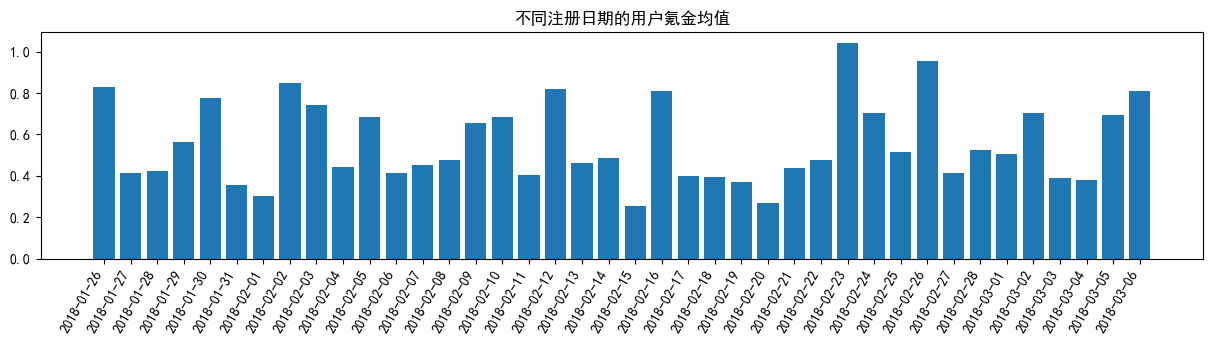

In [132]:
#Draw image
plt.figure(figsize=(15,3),dpi=100)
plt.title("不同注册日期的用户氪金均值")
plt.bar(RegisterDateMean.index, RegisterDateMean.values)
plt.xticks(RegisterDateMean.index,rotation=60,ha="right");

From the picture, it is almost impossible to see the connection between the date and the amount of in-game spending. It seems to be relatively random and messy overall, but there will be a peak every few days. We can try converting the date into seven days of the week and see if there is an obvious relationship between the week and the amount of in-game spending. 

In [135]:
#The string must be converted into a time format that python can read, so that python can help me identify the day of the week based on the date
datetime.datetime.strptime(data.loc[0,"玩家注册时间"][:10],"%Y-%m-%d").weekday()

4

In [ ]:
#weekday - [0,1,2,3,4,5,6]

In [136]:
RegisterWeekday = data.loc[:,"玩家注册时间"].apply(lambda x: datetime.datetime.strptime(x[:10],"%Y-%m-%d").weekday()+1) #1~7 represent Monday to Sunday respectively

In [137]:
RegisterWeekday

0          5
1          5
2          5
3          5
4          5
          ..
2288002    6
2288003    6
2288004    6
2288005    6
2288006    6
Name: 玩家注册时间, Length: 2288007, dtype: int64

In [138]:
RegisterWeekDayMean = data["付费金额"].groupby(RegisterWeekday).mean()

In [139]:
RegisterWeekDayMean

玩家注册时间
1   0.618
2   0.485
3   0.448
4   0.378
5   0.815
6   0.549
7   0.426
Name: 付费金额, dtype: float64

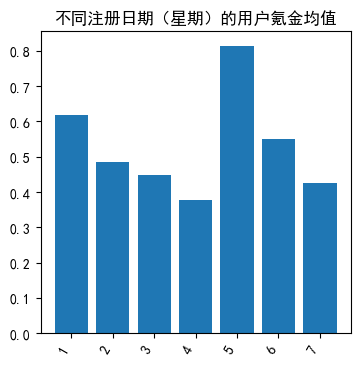

In [140]:
#Draw image
plt.figure(figsize=(4,4),dpi=100)
plt.title("不同注册日期（星期）的用户氪金均值")
plt.bar(RegisterWeekDayMean.index, RegisterWeekDayMean.values)
plt.xticks(RegisterWeekDayMean.index,rotation=60,ha="right");

Obviously, people who registered on Friday and Monday had a higher amount of in-game spending, and it will gradually decrease after the peak. This trend seems to be related to the amount of in-game spending and the week, but in fact it is more likely to be related to the game purchase volume, the rhythm and channels of delivery. Maybe every Friday and every Monday can be queued to the channel where higher-quality users are located, or Friday will attract the attention of a large number of players who are ready to spend the weekend, and Monday will attract the attention of a large number of players who do not want to put in work yet. The peaks on Friday and Monday suggest that the traffic entering these two days may be people who work regularly and have financial income. But no matter what the truth is, from a feature perspective, we can calculate the correlation coefficient between the payment amount of the week and the 45th: 

In [141]:
pd.concat([data["45日付费金额"],RegisterWeekday],axis=1).corr()

,45日付费金额,玩家注册时间
45日付费金额,1.000,0.000
玩家注册时间,0.000,1.000


>The correlation coefficient is very, very small, and the two are almost irrelevant. We can not put the week into the feature matrix. 

In [142]:
# List the time in a separate column and extract the hours as features
RegisterTime = data.loc[:,"玩家注册时间"].apply(lambda x: int(x[11:13]))

In [143]:
RegisterTime

0          19
1           0
2           0
3           0
4           0
           ..
2288002    14
2288003    14
2288004    14
2288005    14
2288006    14
Name: 玩家注册时间, Length: 2288007, dtype: int64

In [144]:
#Aggregation according to player registration time and average value
RegisterTimeMean = data["付费金额"].groupby(RegisterTime).mean()

In [147]:
RegisterTimeMean

玩家注册时间
0    0.543
1    0.432
2    0.350
3    0.400
4    0.390
5    0.427
6    0.427
7    0.363
8    0.371
9    0.335
10   1.268
11   1.028
12   0.726
13   0.520
14   0.570
15   0.640
16   0.725
17   0.450
18   0.465
19   0.383
20   0.388
21   0.432
22   0.599
23   0.571
Name: 付费金额, dtype: float64

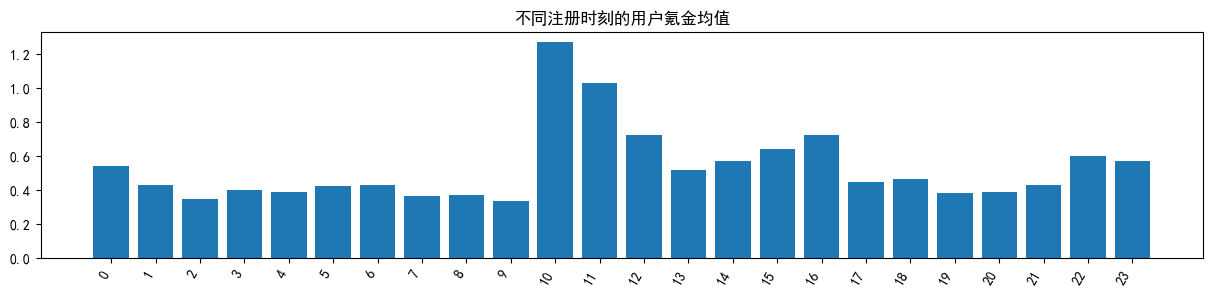

In [148]:
#Draw image
plt.figure(figsize=(15,3),dpi=100)
plt.title("不同注册时刻的用户氪金均值")
plt.bar(RegisterTimeMean.index, RegisterTimeMean.values)
plt.xticks(RegisterTimeMean.index,rotation=60,ha="right");

>Users who registered between 10 a.m. and 12 a.m. and between 4 p.m. and 5 p.m. showed a higher ability to earn money than users who registered at other times. This may be related to the promotion channel, or it may actually be related to the time of registration and the amount of money. Coincidentally, 10 a.m. and 4 p.m. are the time for fishing and drinking tea during working hours. If we can determine which channels are being promoted at this time, we can determine the portraits of relevant users and determine whether the time is really related to the amount of in-game spending. At the same time, let’s also take a look at the correlation coefficient: 

In [149]:
pd.concat([data["45日付费金额"],RegisterTime],axis=1).corr()

,45日付费金额,玩家注册时间
45日付费金额,1.000,0.001
玩家注册时间,0.001,1.000


 It seems that the registration time has a slight relationship (very weak) with the payment amount. We can keep the registration time for modeling purposes. 

Add player registration time as a feature, be sure to add it in front of the label, and keep the label in the last column

In [150]:
data.shape[1]

109

In [151]:
data.insert(data.shape[1]-1,"玩家注册时刻",RegisterTime)

<<<U247>>Now we can delete the original "registration time" feature. At the same time, we can also delete the player's unique ID, because the ID should not be a helpful feature for modeling. 

In [152]:
data.drop(columns=["玩家注册时间","玩家唯一ID"],inplace=True) #Delete unnecessary features

In [153]:
data.columns

Index(['木头获取数量', '木头消耗数量', '石头获取数量', '石头消耗数量', '象牙获取数量', '象牙消耗数量', '肉获取数量',
       '肉消耗数量', '魔法获取数量', '魔法消耗数量',
       ...
       '主动发起PVP次数', 'PVP胜利次数', 'PVE次数', '主动发起PVE次数', 'PVE胜利次数', '在线时长', '付费金额',
       '付费次数', '玩家注册时刻', '45日付费金额'],
      dtype='object', name='字段解释', length=108)

————————————

<<<U249>>### 3. Model selection and benchmark

 In the 2018 DC competition, the team that won the championship on the "Brutal Age" data set achieved RMSE=40. The RMSE value of the top 10 was 55.444, and the RMSE value of the top 20 was 57.67. We can adjust with 50 as the target. Before modeling, we need to build our own benchmark to compare whether our optimization process is effective. <br>
The competition benchmark can be found here: https://js.dclab.run/v2/cmptDetail.html?id=226

In [154]:
data.head()

字段解释,木头获取数量,木头消耗数量,石头获取数量,石头消耗数量,象牙获取数量,象牙消耗数量,肉获取数量,肉消耗数量,魔法获取数量,魔法消耗数量,...,主动发起PVP次数,PVP胜利次数,PVE次数,主动发起PVE次数,PVE胜利次数,在线时长,付费金额,付费次数,玩家注册时刻,45日付费金额
0,20125.000,3700.000,0.000,0.000,0.000,0.000,16375.000,2000.000,0.000,0.000,...,0,0,0,0,0,0.333,0.000,0,19,0.000
1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0,0,0,0,0,0.333,0.000,0,0,0.000
2,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0,0,0,0,0,1.167,0.000,0,0,0.000
3,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0,0,0,0,0,3.167,0.000,0,0,0.000
4,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0,0,0,0,0,2.333,0.000,0,0,0.000


In [170]:
#Extract tags and segment tags and features
X = data.iloc[:,:-1]
y = data.iloc[:,-1]

In [171]:
y.shape

(2288007,)

In [172]:
X.shape

(2288007, 107)

In [158]:
y.head()

0   0.000
1   0.000
2   0.000
3   0.000
4   0.000
Name: 45日付费金额, dtype: float64

Under the requirements of the existing data volume, we must first consider a linear model that is fast and simple to calculate: linear regression. After testing, it takes about half an hour to run a 2 million data set on a random forest of 100 trees, and about 40 minutes to run on an XGBoost of 100 trees. You can change to a tree model according to your needs, but the course recommends using a faster linear model to facilitate running the model and explaining the optimization process. 

**Create benchmark**

In [173]:
from sklearn.linear_model import LinearRegression as LR #Linear regression
from sklearn.model_selection import train_test_split as TTS #Separate the classes of training set and test set
from sklearn.metrics import mean_squared_error as MSE #Model evaluation index

In [174]:
#Data split
Xtrain, Xtest, Ytrain, Ytest = TTS(X,y,test_size=0.3,random_state=1412)

In [175]:
Xtrain.shape

(1601604, 107)

In [176]:
Xtest.shape

(686403, 107)

In [177]:
Xtrain.head()

字段解释,木头获取数量,木头消耗数量,石头获取数量,石头消耗数量,象牙获取数量,象牙消耗数量,肉获取数量,肉消耗数量,魔法获取数量,魔法消耗数量,...,PVP次数,主动发起PVP次数,PVP胜利次数,PVE次数,主动发起PVE次数,PVE胜利次数,在线时长,付费金额,付费次数,玩家注册时刻
243592,10000.000,600.000,0.000,0.000,0.000,0.000,10000.000,400.000,0.000,0.000,...,0,0,0,0,0,0,0.167,0.000,0,19
361662,39038.000,8750.000,0.000,0.000,3000.000,0.000,42434.000,6060.000,0.000,0.000,...,1,0,0,1,1,1,0.833,0.000,0,12
1319519,10000.000,1600.000,0.000,0.000,0.000,0.000,10000.000,900.000,0.000,0.000,...,0,0,0,0,0,0,0.167,0.000,0,15
276423,26625.000,6900.000,0.000,0.000,0.000,0.000,31625.000,3900.000,0.000,0.000,...,1,1,0,0,0,0,4.500,0.000,0,9
1060863,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0,0,0,0,0,0,0.667,0.000,0,4


In [178]:
#The index needs to be restored after splitting
for i in [Xtrain, Xtest]:
    i.index = range(i.shape[0])

In [179]:
Xtrain.head()

字段解释,木头获取数量,木头消耗数量,石头获取数量,石头消耗数量,象牙获取数量,象牙消耗数量,肉获取数量,肉消耗数量,魔法获取数量,魔法消耗数量,...,PVP次数,主动发起PVP次数,PVP胜利次数,PVE次数,主动发起PVE次数,PVE胜利次数,在线时长,付费金额,付费次数,玩家注册时刻
0,10000.000,600.000,0.000,0.000,0.000,0.000,10000.000,400.000,0.000,0.000,...,0,0,0,0,0,0,0.167,0.000,0,19
1,39038.000,8750.000,0.000,0.000,3000.000,0.000,42434.000,6060.000,0.000,0.000,...,1,0,0,1,1,1,0.833,0.000,0,12
2,10000.000,1600.000,0.000,0.000,0.000,0.000,10000.000,900.000,0.000,0.000,...,0,0,0,0,0,0,0.167,0.000,0,15
3,26625.000,6900.000,0.000,0.000,0.000,0.000,31625.000,3900.000,0.000,0.000,...,1,1,0,0,0,0,4.500,0.000,0,9
4,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0,0,0,0,0,0,0.667,0.000,0,4


In [180]:
reg = LR() #Instantiation

In [181]:
reg_benchmark = reg.fit(Xtrain,Ytrain) #Training

In [182]:
reg_benchmark.score(Xtrain,Ytrain) #Score on the training set - R2

0.5604160157526337

In [183]:
reg_benchmark.score(Xtest,Ytest) # Score on test set

0.5581998030190558

In [ ]:
#The model is in a state of underfitting - the scores on the training set and the test set are not very high, and the scores of the two are relatively similar
#The simple linear model is slightly insufficient in learning ability

In [184]:
y_pred = reg_benchmark.predict(Xtest) #Predicted labels on test set

In [186]:
# Root mean square error (RMSE)
np.sqrt(MSE(Ytest,y_pred)) #benchmark is the RMSE of 62, and the r2 of 55.8%

62.00116183660681

<<<U268>>Try using other models for prediction. The current amount of data is too huge for the tree ensemble model, so we can only try it under limited conditions: 

In [187]:
from sklearn.ensemble import RandomForestRegressor as RFR

In [ ]:
# Gives the number of very small trees and limits the maximum number of features used for each branch

In [39]:
reg_tree = RFR(n_estimators=10,max_features=5) #100+，max_features=5

In [40]:
##=====【TIME WARNING：2mins】======##
reg_tree.fit(Xtrain,Ytrain)

RandomForestRegressor(max_features=5, n_estimators=10)

In [41]:
reg_tree.score(Xtrain,Ytrain) #The R2 on the training set is 87%

0.8713222268437917

In [42]:
reg_tree.score(Xtest,Ytest) #The R2 on the test set is 41%

0.412497434944059

In [ ]:
#Random forest is in a state of overfitting - whenever you have the opportunity, you can adjust the parameters of the random forest to resist overfitting and try to use the tree model

In [43]:
y_pred = reg_tree.predict(Xtest)

In [44]:
np.sqrt(MSE(Ytest,y_pred))

70.41454045975792

This is not a good sign. Generally speaking, if a piece of data performs well on a linear model and poorly on a tree model, it means that the distribution pattern of the data is close to a linear pattern, and it is more suitable for models such as linear regression and Bayesian. On the contrary, it means that the distribution of the data is closer to the nonlinear law and more suitable for nonlinear models such as tree models. However, if the tree model and the linear model show similar results, and both results are not high, it means that the data itself is difficult to learn. We can try to adjust the random forest slightly, and we will find that no matter what we do to the model, the RMSE of the model is very high. 

In [45]:
##=====【TIME WARNING：10mins】======##
reg_tree2 = RFR(n_estimators=20,max_features=5).fit(Xtrain,Ytrain) #Increase the number of trees

In [46]:
np.sqrt(MSE(Ytest,reg_tree2.predict(Xtest)))

69.02380701042459

In [47]:
reg_tree3 = RFR(n_estimators=20,max_depth=2,max_features=5).fit(Xtrain,Ytrain) #Control the maximum depth

In [48]:
np.sqrt(MSE(Ytest,reg_tree3.predict(Xtest)))

74.41425794730462

** If you find that the best model is linear regression when establishing a benchmark, there is basically no room for adjustment, because linear regression has almost no parameters that can be adjusted. ** According to experience, when faced with such data, either spend a lot of effort on feature engineering or use neural networks for modeling. But anyway, we first make every effort to reduce the RMSE on the dataset. 

————————————

<<<U277>>### 4. Feature Engineering (1): Add new features according to business model

In the previous analysis of many business models, we have already learned a lot about the business of SLG Games and the game itself. Now we can build new features based on this understanding. When modeling algorithms, we often use the following methods to reorganize existing features to generate new features:

- 1. **addition, subtraction, multiplication and division** between features
- 2. Perform simple **mathematical operations** on the features (absolute value, logarithm)
- 3. Perform **logical operations** on features (and, or, union, intersection, maximum value, minimum value)
- 4. Perform **aggregation operation** on the features (after aggregating discrete features, take the median, mean, mode, standard deviation, variance, and frequency)
- 5. Use the **polynomial** expansion method for features (that is, multiply features by themselves and other features)
- 6. **Binning** on continuous features
- 7. Perform **one-hot encoding** on discrete features

Based on our understanding of the business, in fact there are many features that can be added to the current data set, such as:

> - Personal PVP winning rate = Number of PVP wins/Number of PVP wins. Users without PVP have a winning rate of 0
> - The probability of actively initiating PVP = the number of active PVP initiations/the number of PVP times. Users who do not actively initiate PVP are 0
> - Player development efficiency = average number of resources acquired/online time (people with high indicators are good at games)
> - Player upgrade efficiency = average skill level/online time
> - in-game spending development efficiency = average number of resources acquired/7-day payment amount (people with high indicators make good use of in-game spending resources)
> - in-game spending upgrade efficiency = average skill level/7-day payment amount

You can also bin the features that obviously have an impact on in-game spending, such as the 7-day payment amount and online time, and find the aggregation function of resources, PVP win rate and other features related to the depth of the game experience according to the binned categories. This is especially effective for the tree model. In the limited time, we cannot calculate all the possible added features, so we choose to manually add the above 6 features as an attempt: 

In [49]:
X.columns.tolist() # I can distinguish from my own feature matrix which ones are skills and which ones are resources

['木头获取数量',
 '木头消耗数量',
 '石头获取数量',
 '石头消耗数量',
 '象牙获取数量',
 '象牙消耗数量',
 '肉获取数量',
 '肉消耗数量',
 '魔法获取数量',
 '魔法消耗数量',
 '勇士招募数量',
 '勇士损失数量',
 '驯兽师招募数量',
 '驯兽师损失数量',
 '萨满招募数量',
 '萨满损失数量',
 '勇士伤兵产生数量',
 '勇士伤兵恢复数量',
 '驯兽师伤兵产生数量',
 '驯兽师伤兵恢复数量',
 '萨满伤兵产生数量',
 '萨满伤兵恢复数量',
 '通用加速获取数量',
 '通用加速使用数量',
 '建筑加速获取数量',
 '建筑加速使用数量',
 '科研加速获取数量',
 '科研加速使用数量',
 '训练加速获取数量',
 '训练加速使用数量',
 '治疗加速获取数量',
 '治疗加速使用数量',
 '建筑：士兵小屋等级',
 '建筑：治疗小井等级',
 '建筑：要塞等级',
 '建筑：据点传送门等级',
 '建筑：兵营等级',
 '建筑：治疗之泉等级',
 '建筑：智慧神庙等级',
 '建筑：联盟大厅等级',
 '建筑：仓库等级',
 '建筑：瞭望塔等级',
 '建筑：魔法幸运树等级',
 '建筑：战争大厅等级',
 '建筑：联盟货车等级',
 '建筑：占卜台等级',
 '建筑：祭坛等级',
 '建筑：冒险传送门等级',
 '科研：侦查等级',
 '科研：训练速度等级',
 '科研：守护者',
 '科研：巨兽驯兽师',
 '科研：吟唱者',
 '科研：勇士攻击',
 '科研：驯兽师攻击',
 '科研：萨满攻击',
 '科研：战斗大师',
 '科研：高阶巨兽骑兵',
 '科研：图腾大师',
 '科研：部队防御',
 '科研：勇士防御',
 '科研：驯兽师防御',
 '科研：萨满防御',
 '科研：勇士生命',
 '科研：驯兽师生命',
 '科研：萨满生命',
 '科研：狂战士',
 '科研：龙骑兵',
 '科研：神谕者',
 '科研：部队攻击',
 '科研：建造速度',
 '科研：资源保护',
 '科研：部队消耗',
 '科研：木材生产',
 '科研：石头生产',
 '科研：象牙生产',
 '科研：肉类生产',
 '科研：木材采集',
 '科研：石头采集',
 '科研：象牙采集',
 '科研：肉类采集'

In [188]:
GrowthFeature = [] #Development - the part about resources
for i in X.columns:
    if "招募" in i:
        GrowthFeature.append(i)
    elif "获取" in i:
        GrowthFeature.append(i)

In [189]:
LevelUpFeature = [] #Level - About skills
for i in X.columns:
    if "建筑" in i:
        LevelUpFeature.append(i)
    elif "科研" in i:
        LevelUpFeature.append(i)

In [190]:
GrowthFeature

['木头获取数量',
 '石头获取数量',
 '象牙获取数量',
 '肉获取数量',
 '魔法获取数量',
 '勇士招募数量',
 '驯兽师招募数量',
 '萨满招募数量',
 '通用加速获取数量',
 '建筑加速获取数量',
 '科研加速获取数量',
 '训练加速获取数量',
 '治疗加速获取数量']

In [191]:
LevelUpFeature

['建筑加速获取数量',
 '建筑加速使用数量',
 '科研加速获取数量',
 '科研加速使用数量',
 '建筑：士兵小屋等级',
 '建筑：治疗小井等级',
 '建筑：要塞等级',
 '建筑：据点传送门等级',
 '建筑：兵营等级',
 '建筑：治疗之泉等级',
 '建筑：智慧神庙等级',
 '建筑：联盟大厅等级',
 '建筑：仓库等级',
 '建筑：瞭望塔等级',
 '建筑：魔法幸运树等级',
 '建筑：战争大厅等级',
 '建筑：联盟货车等级',
 '建筑：占卜台等级',
 '建筑：祭坛等级',
 '建筑：冒险传送门等级',
 '科研：侦查等级',
 '科研：训练速度等级',
 '科研：守护者',
 '科研：巨兽驯兽师',
 '科研：吟唱者',
 '科研：勇士攻击',
 '科研：驯兽师攻击',
 '科研：萨满攻击',
 '科研：战斗大师',
 '科研：高阶巨兽骑兵',
 '科研：图腾大师',
 '科研：部队防御',
 '科研：勇士防御',
 '科研：驯兽师防御',
 '科研：萨满防御',
 '科研：勇士生命',
 '科研：驯兽师生命',
 '科研：萨满生命',
 '科研：狂战士',
 '科研：龙骑兵',
 '科研：神谕者',
 '科研：部队攻击',
 '科研：建造速度',
 '科研：资源保护',
 '科研：部队消耗',
 '科研：木材生产',
 '科研：石头生产',
 '科研：象牙生产',
 '科研：肉类生产',
 '科研：木材采集',
 '科研：石头采集',
 '科研：象牙采集',
 '科研：肉类采集',
 '科研：部队负重',
 '科研：魔法采集',
 '科研：魔法生产',
 '科研：据点耐久',
 '科研：据点二',
 '科研：医院容量',
 '科研：领土采集奖励',
 '科研：治疗速度',
 '科研：据点三',
 '科研：联盟行军速度',
 '科研：战斗行军速度',
 '科研：采集行军速度',
 '科研：据点四',
 '科研：增援部队容量',
 '科研：行军大小',
 '科研：资源帮助容量']

In [192]:
X["PVP胜率"] = X["PVP胜利次数"]/X["PVP次数"]
X["主动发起PVP的概率"] = X["主动发起PVP次数"]/X["PVP次数"]
X["玩家发育效率"] = X.loc[:,GrowthFeature].mean(axis=1)/X["在线时长"]
X["氪金发育效率"] = X.loc[:,GrowthFeature].mean(axis=1)/X["付费金额"]
X["玩家升级效率"] = X.loc[:,LevelUpFeature].mean(axis=1)/X["在线时长"]
X["氪金升级效率"] = X.loc[:,LevelUpFeature].mean(axis=1)/X["付费金额"]

In [193]:
#When using division, be sure to check for division-by-zero errors and extreme value errors (the numerator is extremely large or the denominator is extremely small)
#There are many users with 0 PVP times, and their winning rate is also considered to be 0, but when performing division calculations, a null value will be formed 
#And when the numerator is too large and the denominator is too small, inf will be formed. Such users need to judge whether the numerator is too large or the denominator is too small

X["PVP胜率"].isnull().sum()

1712305

In [194]:
X["氪金发育效率"].describe()

C:\ProgramData\Anaconda3\lib\site-packages\numpy\lib\function_base.py:3968: RuntimeWarning: invalid value encountered in multiply
  x2 = take(ap, indices_above, axis=axis) * weights_above


count   1665563.000
mean            inf
std             nan
min           0.000
25%             inf
50%             nan
75%             inf
max             inf
Name: 氪金发育效率, dtype: float64

<<<U286>>Why does the limit value appear? Although some numerators are indeed relatively large, most denominators are actually single digits or very small<br>
The fundamental problem with in-game spending development efficiency is that the amount of many in-game spending is too small (the denominator is too small), not because the numerator is too high<br>
Therefore, for samples with inf problems, use 0 to cover 

In [196]:
#Handle division by 0 errors and extreme value errors
for newfeature in ["PVP胜率","主动发起PVP的概率","玩家发育效率","玩家升级效率","氪金发育效率","氪金升级效率"]:
    X.loc[X[newfeature].isnull(),newfeature] = 0 #Change all null values ​​to 0
    X.loc[X[newfeature] == float("inf"), newfeature] = 0 #Situations where the denominator is very small

In [197]:
X["玩家发育效率"].isnull().sum()

0

In [198]:
(X["氪金发育效率"] == float("inf")).sum()

0

>**I strongly recommend that you try the combination of binning + aggregation. **

<<<U291>>In addition, when we previously analyzed the operating conditions of the game, we have already drawn some key conclusions about user value:
> - When analyzing the revenue situation, we found that if a user **pays more than 6 yuan** within 7 days, the probability of him/her continuing to pay after 7 days is greater than the probability of no longer paying, and he/she is a high-value user<br><br>
> - When analyzing the user's online time, when the user's **online time is less than 15 (20) or greater than 800 (900) minutes**, the user's contribution rate to the in-game spending amount is small, and he is a low-value user<br><br>
> - When analyzing the game competition and game balance, we found that users whose **probability of actively initiating PVP is greater than 50%** contribute more in-game spending and are high-value users<br><br>
> - When analyzing the difficulty of obtaining resources and the friendliness of novices, we found that players whose initial resource (wood) acquisition quantity is 0 or very low are low-value users<br><br>
> - When analyzing outliers, we found that abnormal users cover all paying users, because paying users tend to have a large amount of resources. However, there are also many users who do not spend money and have a lot of resources. They are liver emperors. When their liver reaches a certain level, they will not be able to spend money. Therefore, users who have a huge amount of resources (abnormal) but have not paid within 7 days** are low-value users 

<<<U292>>Based on these findings, we uniformly mark low-value users as 0 and high-value users as 1, and create the following new features for the feature matrix:

- **High Value Players**
> - Potential players: Pay more than 6 yuan within 7 days
> - Militant players: The probability of proactively initiating PVP is greater than 50%

- **Low Value Player**
> - Buddhist players: the probability of actively initiating PVP is less than 20%, or has never participated in PVP once
> - Players of Gan Emperor: The online time for 7 days was too long, or the resources were huge but no payment was made within 7 days.
> - Rookie player: Have participated in PVP and personal PVP winning rate is less than 10%
> - Lost players: The online time in the 7th day is too short, or the initial resource acquisition amount is less than 10,000

In fact, there are quite a few similar features that we can classify in detail, which may involve user behavioral portraits in the game. For example, a "great player" with a high PVP win rate, a "good and brave" player with a lot of PVP but a low win rate, a "green" player who has never played PVP but has a very high PVE win rate and a huge amount of resources. These complicated situations may all be related to the final in-game spending behavior. Now let us proceed with feature derivation based on these findings: 

In [204]:
# High-value players, those who meet the conditions are marked as 1
X["潜力玩家"] = (X["付费金额"] >= 5.98).astype(int)
X["好战玩家"] = (X["主动发起PVP的概率"] >= 0.5).astype(int)

# Low-value players, those who meet the conditions are marked as 0
X["肝帝玩家"] = (X["在线时长"] > 800).apply(lambda x: not x).astype(int)
X["佛系玩家"] = ((X["主动发起PVP的概率"] < 0.2) | (X["PVP次数"] == 0)).apply(lambda x: not x).astype(int)
X["菜鸡玩家"] = ((X["PVP胜率"]< 0.1) & (X["PVP次数"] != 0)).apply(lambda x: not x).astype(int)
X["流失玩家"] = ((X["在线时长"] <= 15) | (X["木头获取数量"] <= 10000)).apply(lambda x: not x).astype(int)

In [205]:
X.isnull().sum().sum()

0

In [206]:
X.head()

字段解释,木头获取数量,木头消耗数量,石头获取数量,石头消耗数量,象牙获取数量,象牙消耗数量,肉获取数量,肉消耗数量,魔法获取数量,魔法消耗数量,...,玩家发育效率,氪金发育效率,玩家升级效率,氪金升级效率,潜力玩家,好战玩家,肝帝玩家,佛系玩家,菜鸡玩家,流失玩家
0,20125.000,3700.000,0.000,0.000,0.000,0.000,16375.000,2000.000,0.000,0.000,...,8446.162,0.000,2.261,0.000,0,0,1,0,1,0
1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0,0,1,0,1,0
2,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0,0,1,0,1,0
3,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0,0,1,0,1,0
4,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0,0,1,0,1,0


————————————

<<<U296>>### 5. Feature Engineering (2): Achieving the statistical assumptions required for modeling

<<<U297>>In order for the data to run effectively in linear regression, we hope to avoid the impact of factors such as outliers and left-skewed distributions. Therefore, we want to do the following preprocessing on the training set:
> 1. **Correlation Analysis**: We can delete features that have insufficient or 0 correlation with the label and observe which features are related to the label
> 2. **Training/Test Ratio Tuning**: Adjust the ratio of training set to test set to find the best test_size hyperparameter
> 3. **Outlier processing**: According to the rules of the box plot, the players with no in-game spending within 7 days among the outliers will be covered by the median, and the players with in-game spending within 7 days will not be processed.
> 4. **Data Normalization**: In order to eliminate the trouble caused by dimensional non-uniformity and speed up calculations in the case of large amounts of data, we need to normalize all feature attributes to the range of [0,1]
> 5. **Data normalization** (optional): From a statistical point of view, normalized feature data is more likely to fit excellent results. We can try the results of box-cox normalized data

#### 5.1 Relevance analysis: filtering features/feature importance

Now the model has more than 100 features. In order to increase the calculation speed/reduce the calculation cost/do a feature derivation method similar to polynomials, we can simply use the correlation coefficient to filter the features. The simplest way is to use the Pearson correlation coefficient.

DataFrame can directly use the function .corr() to calculate the correlation coefficient, but since we have more than 100 features, each feature has 220,000 samples, directly using the corr() function to calculate all features not only takes up a lot of computing memory, but also the calculation will be very slow, so here we simplify it - only consider the correlation between features and labels, and do not consider the statistical issues caused by the correlation between features.

In traditional statistics, if the linear correlation between features is too high, linear regression cannot handle it. However, the linear regression in the sklearn library now uses the SVD decomposition method for calculation, which can overcome the problem that traditional linear regression cannot handle high linear correlation features, so we can ignore this problem. 

In [215]:
corr_list = pd.DataFrame() #Empty DataFrame

In [216]:
for idx, column in enumerate(X.columns):
    corr_ = pd.concat([y,X.loc[:,column]],axis=1).corr().iloc[0,1] #For each column, I calculate the correlation coefficient between this column and the label
    corr_list.loc[idx,"特征"] = column
    corr_list.loc[idx,"相关系数"] = corr_

In [217]:
corr_list.head()

,特征,相关系数
0,木头获取数量,0.640
1,木头消耗数量,0.619
2,石头获取数量,0.648
3,石头消耗数量,0.631
4,象牙获取数量,0.658


In [219]:
corr_list.sort_values("相关系数",ascending=False).head(10) # The deeper you participate in the game, the higher the possibility of earning money

,特征,相关系数
104,付费金额,0.735
4,象牙获取数量,0.658
2,石头获取数量,0.648
5,象牙消耗数量,0.641
0,木头获取数量,0.640
22,通用加速获取数量,0.633
3,石头消耗数量,0.631
28,训练加速获取数量,0.621
1,木头消耗数量,0.619
6,肉获取数量,0.608


In [220]:
corr_list[abs(corr_list["相关系数"]) < 0.01]

,特征,相关系数
106,玩家注册时刻,0.001
117,菜鸡玩家,0.006


Only two features have a correlation coefficient lower than 0.01. We can consider retaining these features uniformly. If we have stricter requirements on features, we can use a threshold of 0.1 or 0.5. After all, the Pearson correlation coefficient is the closer it is to 1, the more relevant it is, and the closer it is to 0, the less relevant it is. 

#### 5.2 Tuning of training/test set split

 Normally when dividing data, we divide it according to the ratio of training set 7 and test set 3. However, considering that we will use linear regression for modeling, linear regression is a low-complexity model with limited learning ability and anti-overfitting ability. Therefore, too many or too few training sets can easily lead to overfitting. For this reason, we can slightly try the split ratio of several sets of training sets and test sets to determine the number of training sets that is most suitable for linear regression. 

In [68]:
X.shape

(2288007, 119)

In [ ]:
# Equivalent to using the learning curve to adjust the test_size parameter

In [221]:
trainr2 = [] #R2 on the training set
testr2 = [] #R2 on the test set
testRMSE = [] #RMSE on the test set
for i in [0.2,0.3,0.4,0.5]:
    Xtrain, Xtest, Ytrain, Ytest = TTS(X,y,test_size=i,random_state=0)
    model = LR().fit(Xtrain,Ytrain)
    trainr2.append(model.score(Xtrain,Ytrain))
    testr2.append(model.score(Xtest,Ytest))
    testRMSE.append(np.sqrt(MSE(Ytest,model.predict(Xtest))))
    print("done")

done
done
done
done


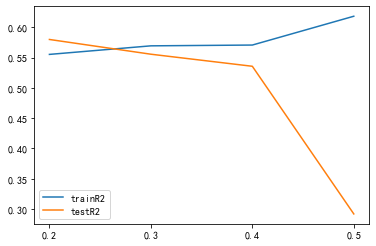

In [222]:
plt.plot(trainr2,label="trainR2")
plt.plot(testr2,label="testR2")
plt.xticks(ticks=[0,1,2,3],labels=[0.2,0.3,0.4,0.5])
plt.legend();

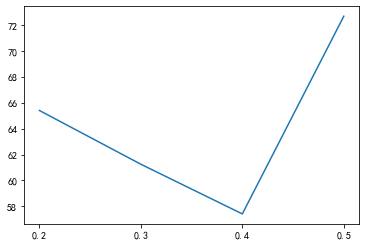

In [223]:
plt.plot(testRMSE)
plt.xticks(ticks=[0,1,2,3],labels=[0.2,0.3,0.4,0.5]);

In [224]:
testRMSE

[65.4079506968015, 61.25139090316119, 57.410190449817, 72.69578370421813]

 From the perspective of results, the number of training sets with the lowest RMSE on the test set is 0.4. From the performance of R2, when the test set ratio is 0.4, R2 on the training set shows a tendency to overfit, but it is not serious. However, considering that the core evaluation index of the current model is RMSE, there is a slight problem with R2, but when RMSE has obvious advantages, we give priority to the performance on RMSE. 

In [225]:
Xtrain, Xtest, Ytrain, Ytest = TTS(X,y,test_size=0.4,random_state=0)

 Pay attention to index operations. Usually after we split the training set and the test set, we need to normalize the index to the range(0,x) series, but this time we do not restore the index, but let the index follow Xtrain and Xtest after the split (the reason will be shown later): 

In [226]:
Ytrain = pd.DataFrame(Ytrain)
Ytest = pd.DataFrame(Ytest)

Ytrain.index = Xtrain.index
Ytest.index = Xtest.index

In [227]:
Xtrain.head()

字段解释,木头获取数量,木头消耗数量,石头获取数量,石头消耗数量,象牙获取数量,象牙消耗数量,肉获取数量,肉消耗数量,魔法获取数量,魔法消耗数量,...,玩家发育效率,氪金发育效率,玩家升级效率,氪金升级效率,潜力玩家,好战玩家,肝帝玩家,佛系玩家,菜鸡玩家,流失玩家
1914412,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0,0,1,0,1,0
188838,26375.000,4200.000,0.000,0.000,0.000,0.000,32000.000,2250.000,0.000,0.000,...,8996.154,0.000,1.536,0.000,0,0,1,0,1,0
1879427,2063.000,1350.000,0.000,0.000,0.000,0.000,1531.000,675.000,0.000,0.000,...,184.308,0.000,0.010,0.000,0,0,1,0,1,0
1616849,56314.000,17460.000,0.000,0.000,0.000,0.000,76717.000,10850.000,0.000,0.000,...,12294.005,0.000,1.026,0.000,0,0,1,0,1,0
2046255,220125.000,3700.000,200000.000,0.000,200000.000,0.000,616375.000,2000.000,60000.000,0.000,...,299367.992,0.000,2.261,0.000,0,0,1,0,1,0


#### 5.3 Exception value handling

When dealing with abnormal values, we found that all in-game spending players were classified into abnormal data. This has a lot to do with the fact that in-game spending players are often deeply involved in the game. Since all players are included in the abnormal data, we cannot simply delete the abnormal data, and because the data is severely left-skewed and the number of abnormal values ​​is large (more than 1 million), it is not advisable to delete 50% of the data. So here, we do special treatment for outliers similar to blocking. Carry out anomaly detection according to the rules of the box plot, and perform median coverage on the abnormal values ​​​​for players who have not made money within 7 days (if the effect is not good enough, you can try to use 0 coverage). Players who have made money within 7 days will not be processed. Try to enlarge the difference in characteristics between players who make money and non-players to provide better protection for modeling.

Note: Outlier processing must be performed when the training set and test set are split, because outlier processing on the test set must rely on the intermediate variables generated by outlier processing on the training set 

In [228]:
import warnings #Code to eliminate warning
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

In [229]:
def AbnormalReplace(Xtrain,Xtest):
    # First perform anomaly detection on all features
    # Users who have paid within 7 days will not be processed
    # For users who have not paid within 7 days, replace all outliers with the median of the current feature or 0
    
    Xtrain_ = Xtrain.copy()
    Xtest_ = Xtest.copy()
    for column in Xtrain_.columns:
        #Extract the column currently to be detected
        f_train = Xtrain_.loc[:,column]
        f_test = Xtest_.loc[:,column]

        #Calculate QL, QU, IQR, and median from the training set
        QL = np.quantile(f_train,0.25)
        QU = np.quantile(f_train,0.75)
        IQR = QU - QL
        medium_ = f_train.median()
        
        # Detect the training set and test set at the same time, and get the True/False list
        errortrain = ((f_train < (QL - 1.5*IQR)).astype(int) + (f_train > (QU + 1.5*IQR)).astype(int)) != 0
        errortest = ((f_test < (QL - 1.5*IQR)).astype(int) + (f_test > (QU + 1.5*IQR)).astype(int)) != 0

        #Replace the outliers in the original matrix with the median, and exclude 7-day paying users from the topic
        #If the effect is not strong enough, try replacing it with 0
        Xtrain_.loc[((Xtrain_["付费金额"]==0).values & errortrain.values),column] = 0 #medium_
        Xtest_.loc[((Xtest_["付费金额"]==0).values & errortest.values),column] = 0 #medium_
        
    return Xtrain_, Xtest_

In [230]:
Xtrain["木头获取数量"].describe()

count      1372804.000
mean        459707.645
std        5253011.374
min              0.000
25%              0.000
50%          41934.000
75%         153061.750
max     1239962311.000
Name: 木头获取数量, dtype: float64

In [231]:
xtrain, xtest = AbnormalReplace(Xtrain,Xtest) #In order to retain the original Xtrain and Xtest, we write the newly generated value in lowercase 

In [232]:
xtrain["木头获取数量"].describe() #View processing data to confirm data changes

count      1372804.000
mean        253442.438
std        5186103.010
min              0.000
25%              0.000
50%          10000.000
75%          96271.250
max     1239962311.000
Name: 木头获取数量, dtype: float64

#### 5.4 Normalization processing

In [ ]:
#Accelerate the operation and unify the dimensions of each feature - when using linear regression, you can check the coefficients to determine the importance of the feature

In [233]:
from sklearn.preprocessing import MinMaxScaler #[0,1] The most commonly used basic method, x - x.min() / x.max() - x.min()

In [234]:
mm = MinMaxScaler(feature_range = [0,1]) #Instancing, [0,1]

In [235]:
mm = mm.fit(xtrain) #Training - generated the minimum and maximum values ​​on the training set

In [236]:
xtrain = mm.transform(xtrain) #Use the minimum and maximum values ​​on the training set to normalize the training set/test set simultaneously
xtest = mm.transform(xtest)

In [237]:
xtrain.min()

0.0

In [238]:
xtrain.max()

1.0

In [239]:
xtest.min()

0.0

In [240]:
xtest.max()

1.3636363636363638

<<<U330>>#### 5.5 Normalization processing (optional)

from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='box-cox') #can only be applied to positive numbers

pt = pt.fit(xtrain)

xtrain = pt.transform(xtrain)
xtest = pt.transform(xtest)

<<<U332>>Theoretically, normalization processing is beneficial to linear regression modeling. However, after many attempts, it was found that the current data will be seriously unstable after normalization processing, which may directly increase the RMSE by tens or even thousands. Therefore, normalization processing is not adopted in this case. 

————————————

### 6. Model fusion: Problems caused by dealing with extremely skewed data

When processing outliers, we found that all users who spent money were included in the abnormal users. This shows that there are a large number of users who did not spend money and their behavior in terms of accumulation of game resources and depth of game participation was very similar to that of users who paid money. At the same time, the user composition of both paying users and non-paying users is relatively complex.

Among the paying users, there are those who close their eyes and spend ¥0.99 within one minute after entering the game, and there are also players who have not spent 7 days in the game, but then suddenly lost a little bit for some reason after the 7th day. Among users who don’t spend money, there are players who are deeply involved in the game but don’t spend a penny to spend money, and there are also players who play badly but never quit playing. Therefore, before prediction, you can actually imagine that the model may not be very effective in user identification and amount prediction.

In the previous feature processing, we have "blocked" outliers and added features that we think can make the difference between paying users and non-paying users larger. However, it is very difficult to directly predict the amount of paying users with a single model. Therefore, we can use two models for fusion prediction. The first model is a classification model logistic regression. We let the logistic regression first predict whether users will make in-game purchases or not, and then put the users who are considered by the logistic regression to be willing to make in-game purchases into linear regression, and then let the linear regression directly predict the amount of money spent on users who are "always likely to make in-game purchases." We believe that such an approach should be able to improve model performance after appropriate adjustments. 

 - Create y used in logistic regression

In [ ]:
#Logistic regression labels: in-game spending (1) and non-in-game spending (0), category 1 is far less than category 0

In [241]:
y2 = (y != 0).astype(int) # All users who spend money are converted to 1, and users who do not use gold are converted to 0

In [242]:
y2.head()

0    0
1    0
2    0
3    0
4    0
Name: 45日付费金额, dtype: int32

In [243]:
y2.value_counts() #45988 - Users with in-game spending amount within 45 days

0    2242019
1      45988
Name: 45日付费金额, dtype: int64

In [253]:
1 - 45988/y2.shape[0]

0.9799004111438471

In [ ]:
#Xtrain,

 Note that the index of y2 at this time is the same as the y before splitting, but the index of xtrain we will use for training is after splitting, so we need to split y2 according to the index of split Xtrain and Xtest. This is why we did not change the index of Xtrain and Xtest to range (0,x) before. Once modified, we will lose the connection between the segmented combination and the original X, y, and we will not be able to construct the test part and training part of the new label y2. 

In [244]:
Xtrain.head()

字段解释,木头获取数量,木头消耗数量,石头获取数量,石头消耗数量,象牙获取数量,象牙消耗数量,肉获取数量,肉消耗数量,魔法获取数量,魔法消耗数量,...,玩家发育效率,氪金发育效率,玩家升级效率,氪金升级效率,潜力玩家,好战玩家,肝帝玩家,佛系玩家,菜鸡玩家,流失玩家
1914412,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0,0,1,0,1,0
188838,26375.000,4200.000,0.000,0.000,0.000,0.000,32000.000,2250.000,0.000,0.000,...,8996.154,0.000,1.536,0.000,0,0,1,0,1,0
1879427,2063.000,1350.000,0.000,0.000,0.000,0.000,1531.000,675.000,0.000,0.000,...,184.308,0.000,0.010,0.000,0,0,1,0,1,0
1616849,56314.000,17460.000,0.000,0.000,0.000,0.000,76717.000,10850.000,0.000,0.000,...,12294.005,0.000,1.026,0.000,0,0,1,0,1,0
2046255,220125.000,3700.000,200000.000,0.000,200000.000,0.000,616375.000,2000.000,60000.000,0.000,...,299367.992,0.000,2.261,0.000,0,0,1,0,1,0


In [248]:
Ytrain2 = y2[Xtrain.index] # Split y2 using the splitting method of Xtrain and Xtest, so that y2 matches Ytrain

In [249]:
Ytest2 = y2[Xtest.index]

In [250]:
Ytrain2.head() #Note that the index is relative to the original 

1914412    0
188838     0
1879427    0
1616849    0
2046255    0
Name: 45日付费金额, dtype: int32

- Model using logistic regression and evaluate using ROC

In [251]:
from sklearn.linear_model import LogisticRegression as LogiR
from sklearn.metrics import roc_auc_score as ROC #ROC
from sklearn.metrics import recall_score as Recall #Recall
from sklearn.metrics import precision_score as Precision #Accuracy

In [254]:
clf = LogiR(random_state=0) #Instancing of logistic regression

In [255]:
clf.fit(xtrain,Ytrain2) #Training, using the feature matrix xtrain that has undergone all feature engineering

LogisticRegression(random_state=0)

In [256]:
clf.score(xtrain,Ytrain2) #Accuracy rate of logistic regression on the training set

0.9968094498559154

In [257]:
clf.score(xtest,Ytest2) #Accuracy rate of logistic regression on the test set

0.9968302114394293

In [262]:
#Fitting situation of test set
y2_proba = clf.predict_proba(xtest) # Find out the probability of each sample predicted by logistic regression on the test set

In [263]:
y2_proba

array([[0.99489246, 0.00510754],
       [0.99814666, 0.00185334],
       [0.99821666, 0.00178334],
       ...,
       [0.99808411, 0.00191589],
       [0.99753833, 0.00246167],
       [0.99817061, 0.00182939]])

In [258]:
y2_proba[:,1] #Extract the probability of 1

array([0.00510754, 0.00185334, 0.00178334, ..., 0.00191589, 0.00246167,
       0.00182939])

In [259]:
ROC(Ytest2,y2_proba[:,1]) #The closer to 1, the better (the closer to 0, the better), the worst case is close to 0.5

0.9712748966963473

- RECALL: Among all real 1s, the proportion of correctly predicted 1s 

![](http://pictes.oss-cn-beijing.aliyuncs.com/%E5%BE%AE%E8%AF%BE%20-%20sklearn/week%208%20SVM%20%282%29/confusion%20matrix/Recall.PNG)

In [260]:
Recall(Ytest2,clf.predict(xtest))

0.8421310404875925

- PRECISION: Among all values ​​predicted to be 1, the proportion of true 1

![](http://pictes.oss-cn-beijing.aliyuncs.com/%E5%BE%AE%E8%AF%BE%20-%20sklearn/week%208%20SVM%20%282%29/confusion%20matrix/Precision.PNG)

In [261]:
Precision(Ytest2,clf.predict(xtest))

1.0

The results of logistic regression are unexpectedly good and can reach an ROC of 0.98 when the sample imbalance is so severe, proving that the data is very suitable for logistic regression. 

- Adjust threshold to increase Recall

The combination of recall and precision shows that all values predicted to be 1 are predicted correctly, but there are still some values predicted to be 0. In fact, the real value is 1. Under this recall and precision, the number of Type 1 (paying users) captured by the test set is: 

In [102]:
(y2_proba[:,1] > 0.5).sum()

15771

The actual number of paying users is: 

In [103]:
(Ytest != 0).sum()

45日付费金额    18376
dtype: int64

 In other words, there are many paying users who have been classified by logistic regression into the "non-in-game spending" category. If modeled according to the current results, the main source of RMSE is **the amount of paying users not included in the logistic regression + the amount difference after being pointed to payment by logistic regression and predicted by linear regression (Situation A)**.

If we hope that logistic regression can capture all real paying users, even if we accidentally hurt some users who do not have in-game spending, then we must work hard to improve Recall. At this time, the main source of RMSE is **the predicted value in linear regression of non-paying users who are mistaken for paying users by logistic regression + the difference in amount of all real paying users after linear regression prediction (situation B)**. Note that in this case more values ​​need to be predicted by linear regression.

The embarrassment is that we don't know which of the two conditions will have an overall lower RMSE, but we know that the current situation is condition A. If we need to improve Recall, we can lower the threshold used for classification in logistic regression.

In logistic regression, when the probability is predicted, we generally think that the threshold is 0.5. When the probability is greater than 0.5, the label of the sample is 1, and when the probability is less than 0.5, the label of the sample is 0. If you want to improve Recall, you can lower the model's threshold. However, logistic regression in sklearn does not provide this function, so we need to calculate the Recall after adjusting the threshold ourselves. Take a look at the following code: 

In [104]:
#Find the class 1 probability predicted by the model
prob = y2_proba[:,1]

In [105]:
#Try to replace the threshold
(prob > 0.3).astype(int) #Prediction label with threshold value 0.3

array([0, 0, 0, ..., 0, 0, 0])

In [106]:
# Loop through 20 threshold alternatives from 0 to 0.5. You will find that the lower the threshold, the higher the recall
for tol in np.linspace(0,0.5,20):
    pred = (prob >= tol).astype(int)
    recall = Recall(Ytest2,pred)
    print("{:.3f} Recall:{:.3f}".format(tol,recall))

0.000 Recall:1.000
0.026 Recall:0.913
0.053 Recall:0.888
0.079 Recall:0.868
0.105 Recall:0.867
0.132 Recall:0.867
0.158 Recall:0.866
0.184 Recall:0.866
0.211 Recall:0.866
0.237 Recall:0.865
0.263 Recall:0.865
0.289 Recall:0.864
0.316 Recall:0.863
0.342 Recall:0.863
0.368 Recall:0.862
0.395 Recall:0.861
0.421 Recall:0.860
0.447 Recall:0.859
0.474 Recall:0.859
0.500 Recall:0.858


In [107]:
for tol in np.linspace(0,0.026,20): #Choose a smaller threshold between 0~0.026
    pred = (prob >= tol).astype(int)
    recall = Recall(Ytest2,pred)
    print("{:.3f} Recall:{:.3f}".format(tol,recall))

0.000 Recall:1.000
0.014 Recall:0.936
0.027 Recall:0.913
0.041 Recall:0.902
0.055 Recall:0.885
0.068 Recall:0.871
0.082 Recall:0.868
0.096 Recall:0.867
0.109 Recall:0.867
0.123 Recall:0.867
0.137 Recall:0.867
0.151 Recall:0.866
0.164 Recall:0.866
0.178 Recall:0.866
0.192 Recall:0.866
0.205 Recall:0.866
0.219 Recall:0.865
0.233 Recall:0.865
0.246 Recall:0.865
0.260 Recall:0.865


In [108]:
#Default threshold
#Current status: 0.5
# It is possible to increase recall and reduce the value of RMSE: try 0.026
# It may increase recall, but it may accidentally injure too many category 0 values, causing RMSE to increase: try 0.014

tol_ = 0.02 #After many experiments, it was confirmed that the threshold 0.02 may be a more appropriate value

In [109]:
#At the 0.02 threshold, logistic regression predicts how many samples in the test set are 1
(y2_proba[:,1] >= tol_).sum()

38184

In [110]:
#How many samples in the training set are predicted to be 1
(clf.predict_proba(xtrain)[:,1] >= tol_).sum()

57165

The above is the amount of data we need to bring into linear regression for modeling. 

 - Preserve the prediction results of logistic regression when the threshold is 0.02

In [111]:
# For all non-in-game spending samples, the prediction has ended here - the label y is 0
#Test set, don’t forget to import the Xtest index into 
result = pd.DataFrame(y2_proba[:,1],index=Xtest.index)
result.columns = ["logi_proba"]
result["logi_y_pred"] = (result["logi_proba"] >= tol_).astype(int)

In [112]:
result.head()

,logi_proba,logi_y_pred
660869,0.001033,0
1002543,0.001454,0
2044898,0.001400,0
961802,0.001083,0
793236,0.001191,0


In [113]:
#Training set, the same index needs to be imported 
logi_train_result = pd.DataFrame(clf.predict_proba(xtrain)[:,1],index=Xtrain.index)
logi_train_result.columns = ["logi_train_proba"]
logi_train_result["logi_y_pred_train"] = (logi_train_result["logi_train_proba"] >= tol_).astype(int)

In [114]:
logi_train_result.head()

,logi_train_proba,logi_y_pred_train
1914412,0.001444,0
188838,0.001325,0
1879427,0.001293,0
1616849,0.001350,0
2046255,0.001498,0


- Select the training set and test set that should be released in linear regression 

In [115]:
#Training set: The part where the prediction label of logistic regression is 1
xtrain_linear_reg = xtrain[logi_train_result["logi_y_pred_train"] == 1]
ytrain_linear_reg = Ytrain[logi_train_result["logi_y_pred_train"] == 1]

In [116]:
xtrain_linear_reg.shape # Confirm that it is consistent with the number of samples predicted to be 1 in the training set

(57165, 119)

In [117]:
#Test set
xtest_linear_reg = xtest[result["logi_y_pred"] == 1]
ytest_linear_reg = Ytest[result["logi_y_pred"] == 1]

In [118]:
xtest_linear_reg.shape

(38184, 119)

-Start regression prediction

In [119]:
def reg_predict(model):
    reg = model.fit(xtrain_linear_reg, ytrain_linear_reg) #Training
    y_linear_pred = reg.predict(xtest_linear_reg) #Predict the test set
    print("Training-set R²: {:.3f}".format(reg.score(xtrain_linear_reg, ytrain_linear_reg)))
    print("Test-set R²: {:.3f}".format(reg.score(xtest_linear_reg, ytest_linear_reg)))
    print("Test-set RMSE: {:.3f}".format(np.sqrt(MSE(ytest_linear_reg,y_linear_pred))))
    return y_linear_pred #Regression part of the results predicted by the fusion model

In [120]:
#Linear Regression
reg0 = LR()

In [121]:
y_linear_pred0 = reg_predict(reg0) #There are no parameters that can be adjusted

训练集R2:0.582
测试集R2:0.538
测试集RMSE:277.579


In [122]:
from sklearn.ensemble import RandomForestRegressor as RFR
from sklearn.ensemble import GradientBoostingRegressor as GBR

In [123]:
reg1 = RFR(n_estimators=100,max_depth=2,max_features=20,random_state=1412)
reg2 = GBR(n_estimators=100,max_depth=2,max_features=20,random_state=1412)

In [124]:
y_linear_pred1 = reg_predict(reg1) #The random forest algorithm is not suitable for the current data

训练集R2:0.521
测试集R2:0.430
测试集RMSE:308.283


In [125]:
y_linear_pred2 = reg_predict(reg2)

训练集R2:0.735
测试集R2:0.533
测试集RMSE:279.156


### 7. Model tuning

In [265]:
#Learning curve, cross-validation, grid search - all aside

- Experience parameter adjustment

In [126]:
reg2 = GBR(n_estimators = 490 #The first consideration is to increase the number of trees in the model to improve the overall fitting ability
           ,max_depth= 2 #But it is easy to overfit, so control the depth of the tree
           ,learning_rate= 0.05 #When n_estimators and max_depth cannot produce good results, consider reducing the learning rate. The learning rate has a great impact on the effect of the tree model
           ,max_features = 50 #max_features exists mainly to control the modeling speed at the beginning, but it can also control overfitting. You can use the learning curve to find the appropriate stage and position
           ,min_samples_split = 25 #If the model is still overfitting, you can try to increase min_samples_split and increase the number of samples allowed to be divided into leaves, so as to reduce the fitting degree of the tree
           ,random_state= 1412)

In [127]:
y_linear_pred2 = reg_predict(reg2)

训练集R2:0.795
测试集R2:0.586
测试集RMSE:262.749


- Combine predictions from linear regression and logistic regression

In [128]:
result["reg_result"] = 0 #Create a new column, all 0

In [129]:
#Pull out the samples whose prediction label of logistic regression is 1, and fill in the regression prediction result y_linear_pred
result.loc[result["logi_y_pred"] == 1,"reg_result"] = y_linear_pred2

In [130]:
result.head()

,logi_proba,logi_y_pred,reg_result
660869,0.001033,0,0.0
1002543,0.001454,0,0.0
2044898,0.001400,0,0.0
961802,0.001083,0,0.0
793236,0.001191,0,0.0


In [131]:
Ytest.head() # Confirm that the index is consistent

,45日付费金额
660869,0.0
1002543,0.0
2044898,0.0
961802,0.0
793236,0.0


In [132]:
np.sqrt(MSE(Ytest,result["reg_result"]))

54.422094868663

Let’s see where this score can help us rank~

![](https://skojiangdoc.oss-cn-beijing.aliyuncs.com/micro_class/sklearncase/%E6%8E%92%E8%A1%8C%E6%A6%9C.PNG)

In [144]:
FeatureImportance = pd.concat([pd.DataFrame(Xtrain.columns),pd.DataFrame(reg2.feature_importances_)],axis=1)

In [147]:
FeatureImportance.sort_values(0,ascending=False) #Feature Importance

,字段解释,0
104,付费金额,0.249891
105,付费次数,0.083299
28,训练加速获取数量,0.068863
4,象牙获取数量,0.066772
23,通用加速使用数量,0.062143
...,...,...
82,科研：魔法采集,0.000000
85,科研：据点二,0.000000
57,科研：高阶巨兽骑兵,0.000000
94,科研：增援部队容量,0.000000


- **Room for improvement**
> 1. Use aggregation to create features
> 2. Use binning to process continuous features (exceptionally good for linear regression)
> 3. Replace with more powerful algorithms (such as neural network/LGBM) 